# Hand Gesture Recognition

In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from scipy.fft import fft, fftfreq
from scipy import signal
from scipy.signal import butter
from numpy import mean, std

from enum import IntEnum

from sklearn.preprocessing import RobustScaler

from pickle import dump

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import libemg

import gc

In [116]:
# global variables
TEST_SUBJECTS = ("gilbert", "nad")
DATA_DIR = "../../recordings/"
SENSOR_PLACEMENT = 0
# GESTURES =  ("fist", "index", "ok", "peace", "thumb", "up", "down")
# GESTURES =  ("fist", "index", "ok", "peace", "thumb", "open", "up", "down", "lift")
GESTURES =  ("fist", "index", "middle", "ok", "peace", "thumb", "baseline")
DAYS = ("31", "27", "19")
NUM_CLASSES = len(GESTURES)
lf = 20
hf = 500
fs = 1150
trim = 4 * 8 * 5
bandpass_order = 4
outlier_rejection_stds = 6

PLOT_ALL_TIMELINE = True
NUM_SENSORS = 4
NUM_READINGS = 8
RANDOM_STATE = 42
SUBSAMPLE_DATA = False

In [117]:
import re

def check_sensors_present(file, num_sensors=NUM_SENSORS):
    df = pd.read_csv(file)
    return len(df.columns) >= num_sensors * NUM_READINGS

# structure: recordings/date/data/*.csv
recordings = []
baseline_file = None

pattern = re.compile(rf"({'|'.join(TEST_SUBJECTS)})_({'|'.join(GESTURES)})\d*_{SENSOR_PLACEMENT}.csv")
# pattern = re.compile(rf"({'|'.join(TEST_SUBJECTS)})_({'|'.join(GESTURES)})1_{SENSOR_PLACEMENT}.csv")

for date_dir, _, filenames in os.walk(DATA_DIR):
    if date_dir.endswith('data') and any(day in date_dir for day in DAYS) and not 'static' in date_dir:
        for filename in filenames:
            if pattern.match(filename):
                gesture = next((gesture for gesture in GESTURES if gesture in filename), None)
                                
                emg_data_file = os.path.join(date_dir, filename)
                if check_sensors_present(emg_data_file):
                    recordings.append({
                        "gesture": gesture,
                        "raw_data_filepath": emg_data_file,
                        "imu_data_filepath": os.path.join(date_dir, f'imu_{filename}') if os.path.exists(os.path.join(date_dir, f'imu_{filename}')) else None,
                        'fft_data_filepath': os.path.join(date_dir, f'fft_{filename}') if os.path.exists(os.path.join(date_dir, f'fft_{filename}')) else None,
                    })
                else:
                    print(f"File {emg_data_file} has the wrong number of sensors. Should be {NUM_SENSORS}. Skipping.")

print(recordings)


[{'gesture': 'ok', 'raw_data_filepath': '../../recordings/27_12_24/data/nad_ok1_0.csv', 'imu_data_filepath': '../../recordings/27_12_24/data/imu_nad_ok1_0.csv', 'fft_data_filepath': '../../recordings/27_12_24/data/fft_nad_ok1_0.csv'}, {'gesture': 'fist', 'raw_data_filepath': '../../recordings/27_12_24/data/nad_fist2_0.csv', 'imu_data_filepath': '../../recordings/27_12_24/data/imu_nad_fist2_0.csv', 'fft_data_filepath': '../../recordings/27_12_24/data/fft_nad_fist2_0.csv'}, {'gesture': 'baseline', 'raw_data_filepath': '../../recordings/27_12_24/data/nad_baseline_0.csv', 'imu_data_filepath': '../../recordings/27_12_24/data/imu_nad_baseline_0.csv', 'fft_data_filepath': '../../recordings/27_12_24/data/fft_nad_baseline_0.csv'}, {'gesture': 'thumb', 'raw_data_filepath': '../../recordings/27_12_24/data/nad_thumb1_0.csv', 'imu_data_filepath': '../../recordings/27_12_24/data/imu_nad_thumb1_0.csv', 'fft_data_filepath': '../../recordings/27_12_24/data/fft_nad_thumb1_0.csv'}, {'gesture': 'fist', 'r

In [118]:
dfs = [[] for _ in range(NUM_CLASSES)]

for recording in recordings:
    dfs[GESTURES.index(recording["gesture"])].append(pd.read_csv(recording["raw_data_filepath"], header=None))

Optional subsampling:

In [119]:
def get_min_df_array_len(dfs):
    min_len = min([len(df_) for df in dfs for df_ in df])
    return min_len

def get_min_df_len(dfs):
    min_len = min([len(df) for df in dfs])
    return min_len

def get_random_df_chunk(df, chunk_len):
    if len(df) == chunk_len:
        return df.iloc[:, 0:(NUM_SENSORS*NUM_READINGS)]
    start = np.random.randint(0, len(df) - chunk_len)
    return df.iloc[start:start+chunk_len, 0:(NUM_SENSORS*NUM_READINGS)]

In [120]:
print([len(df_) for df in dfs for df_ in df])

[4070, 7677, 4554, 5223, 8084, 4874, 5880, 4805, 5139, 6671, 4797, 5276, 7050, 4807, 5406, 6471, 4805, 5347, 6009, 5833, 2297, 4229]


In [121]:
concat_dfs = []

min_len = get_min_df_array_len(dfs)
print(min_len)
for i in range(NUM_CLASSES):
    if SUBSAMPLE_DATA:
        concat_dfs.append(pd.concat([get_random_df_chunk(df, min_len) for df in dfs[i]], ignore_index=True, axis=0))
    else:
        concat_dfs.append(pd.concat(dfs[i], ignore_index=True).iloc[:, 0:(NUM_SENSORS*NUM_READINGS)])

2297


In [122]:
print([len(df) for df in concat_dfs])

[21524, 18838, 9944, 16744, 17263, 16623, 18368]


Combine dataframes

In [123]:
sensor_data = pd.concat(concat_dfs, ignore_index=True, axis=0)
labels = sum([[i] * len(concat_dfs[i]) for i in range(NUM_CLASSES)], [])
print(sensor_data.head())

      0      1      2      3      4      5      6      7      8      9   ...  \
0  18413  18430  18428  18439  18424  18427  18445  18429  18277  18282  ...   
1  18413  18430  18428  18439  18424  18427  18445  18429  18255  18272  ...   
2  18413  18430  18428  18439  18424  18427  18445  18429  18255  18272  ...   
3  18354  18370  18400  18399  18360  18353  18352  18361  18255  18272  ...   
4  18354  18370  18400  18399  18360  18353  18352  18361  18255  18272  ...   

      22     23     24     25     26     27     28     29     30     31  
0  18200  18210  18285  18313  18350  18345  18334  18346  18360  18342  
1  18135  18164  18285  18313  18350  18345  18334  18346  18360  18342  
2  18135  18164  18303  18244  18294  18308  18288  18305  18322  18327  
3  18135  18164  18303  18244  18294  18308  18288  18305  18322  18327  
4  18135  18164  18303  18244  18294  18308  18288  18305  18322  18327  

[5 rows x 32 columns]


## Preprocessing

In [124]:
import libemg
import numpy as np
from numpy import mean, std
from scipy import signal
from scipy.signal import butter


class EMG_preprocessor():
    def __init__(self, lf, hf, fs, trim, filter_order, outlier_rejection_stds, baseline_signal=None, filter_type='band', library='scipy', num_sensors=4):
        self.lf = lf
        self.hf = hf
        self.fs = fs
        self.trim = trim
        self.filter_order = filter_order
        self.outlier_rejection_stds = outlier_rejection_stds
        self.filter_type = filter_type
        self.library = library
        self.num_sensors = num_sensors
        self.baseline_mean = [[0.0] for _ in range(num_sensors)]
        self.baseline_noise = [[0.0] for _ in range(num_sensors)]
        if baseline_signal is not None:
            self.baseline_signal = [[] for _ in range(num_sensors)]
            baseline_signal = np.array_split(baseline_signal, num_sensors, axis=1)
            for i in range(num_sensors):
                self.baseline_signal[i] = np.asarray(baseline_signal[i]).flatten()
                
            print('Baseline signal provided')
            self._calculate_baseline_noise(filter=True) # calculates baseline noise for each sensor
            self._calculate_baseline_mean() # calculates baseline mean for each sensor
            for i in range(num_sensors):
                self.baseline_signal[i] = self.baseline_signal[i] - self.baseline_mean[i]
        else:
            self.baseline_signal = None

    def calibrate(self, sensor_data):
        self.library = self._maximize_SNR(sensor_data)

    def preprocess(self, sensor_data, sensor_num):
        if self.library == 'scipy':
            return self._preprocess_data_scipy(sensor_data, sensor_num)
        elif self.library == 'libemg':
            return self._preprocess_data_libemg(sensor_data, sensor_num)
        else:
            return sensor_data
        
    def _preprocess_data_libemg(self, data, sensor_num):
        # instantiate the filter object with the sampling frequency
        fi = libemg.filtering.Filter(self.fs)
        # install filters to the filter object
        fi.install_common_filters()
        # run the entire first subject dataset through the common filters
        raw_data = fi.filter(data)
        return raw_data
    
    # def _preprocess_data_emg_dsp_lib(self, data, sensor_num):
    #     ref_available = True if self.baseline_signal is not None else False
    #     self.emg_filter = EMG_filter(sample_frequency = self.fs, range_ = 0.5, min_EMG_frequency = self.lf, max_EMG_frequency = self.hf, reference_available = ref_available)
    #     sig = self.emg_filter.filter(data, self.baseline_signal[sensor_num].tolist())
    #     return sig

    def _remove_mean(self, data):
        return data - np.mean(data, axis=0)

    def _preprocess_data_scipy(self, data, sensor_num):
        data = self._apply_filter(data)
        data = self._remove_artefact(data)
        data = self._remove_outliers(data)
        data = self._remove_mean(data)
        if self.baseline_signal is not None:
            data = self._subtract_baseline(data, sensor_num)
        return data
    
    def _preprocess_baseline_scipy(self, data):
        data = self._apply_filter(data)
        data = self._remove_artefact(data)
        data = self._remove_outliers(data)
        return data
    
    def _apply_filter(self, data):
        if self.filter_type == 'band':
            return self._apply_bandpass_filter(data)
        elif self.filter_type == 'highlow':
            return self._apply_highpasslowpass_filter(data)
        else:
            return data

    def _apply_bandpass_filter(self, data):
        sos = butter(self.filter_order, (self.lf, self.hf), btype="bandpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, data)
        return proc_data
    
    def _apply_highpasslowpass_filter(self, data):
        sos = butter(self.filter_order, self.lf, btype="highpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, data)
        sos = butter(self.filter_order, self.hf, btype="lowpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, proc_data)
        return proc_data

    def _remove_outliers(self, data):
        raw_data = data.flatten()
        data_mean, data_std = mean(raw_data), std(raw_data)
        cut_off = data_std * self.outlier_rejection_stds
        lower, upper = data_mean - cut_off, data_mean + cut_off

        outliers_removed = [x if x >= lower and x <= upper else 0.0 for x in raw_data]
        return outliers_removed

    def _remove_artefact(self, data):
        data[:self.trim] = 0
        return data
    
    def _calculate_baseline_mean(self):
        for i in range(self.num_sensors):
            self.baseline_mean[i] = np.mean(self.baseline_signal[i], axis=0)
    
    def _calculate_baseline_noise(self, filter=False):
        for i in range(self.num_sensors):
            baseline_signal = self.baseline_signal[i]
            if filter:
                baseline_signal = self._preprocess_baseline_scipy(baseline_signal)
            self.baseline_noise[i] = np.sqrt(np.sum(np.asanyarray(baseline_signal)**2)) / len(baseline_signal)
            print('Baseline noise: ', self.baseline_noise[i])
    
    def signaltonoise(self, signal, sensor_num):
        power_signal = np.sqrt(np.sum(np.asanyarray(signal)**2)) / len(signal)
        snr = 10 * np.log10(power_signal / self.baseline_noise[sensor_num])
        return snr

    def _subtract_baseline(self, data, sensor_num):
        return data - self.baseline_signal[sensor_num]

# Data visualization

## Sensor signals

In [125]:
def plot_time_signals(dataframe, row_index, title):
    row_data = dataframe.iloc[row_index, :]

    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(row_data.values, NUM_SENSORS, axis=0)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_time_signals(dataframe, title, preprocessor=None, filter=False):    
    # Plot each sensor's signal
    signals = np.array_split(dataframe.values, NUM_SENSORS, axis=1)
    fig, axs = plt.subplots(NUM_SENSORS // 2 + NUM_SENSORS % 2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, NUM_SENSORS):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        if filter:
            print('Raw SNR: ', preprocessor.signaltonoise(sigs, sensor))
            sigs = preprocessor.preprocess(sigs, sensor)
            print('Processed SNR: ', preprocessor.signaltonoise(sigs, sensor))
        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()

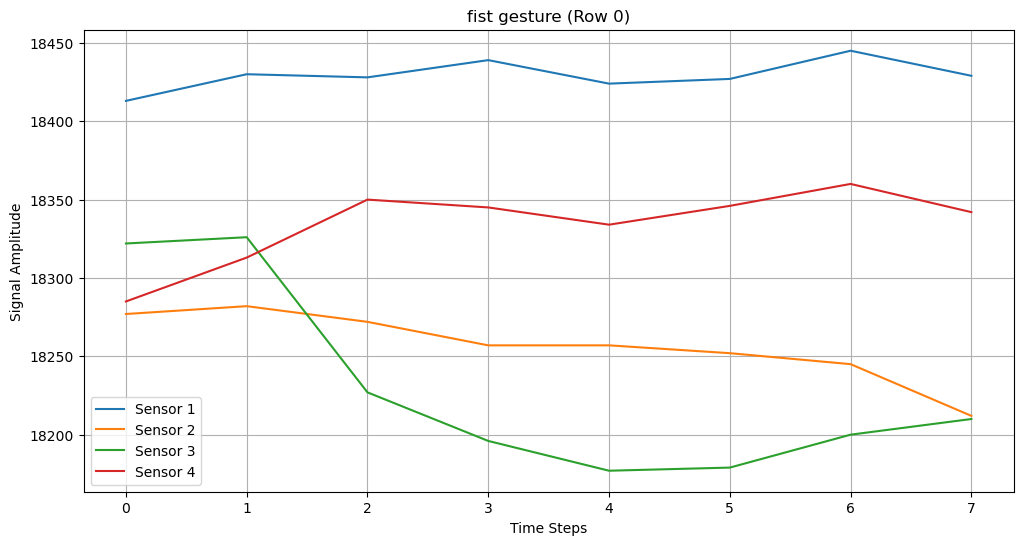

In [126]:
plot_time_signals(concat_dfs[0], row_index=0, title=f'{GESTURES[0]} gesture')

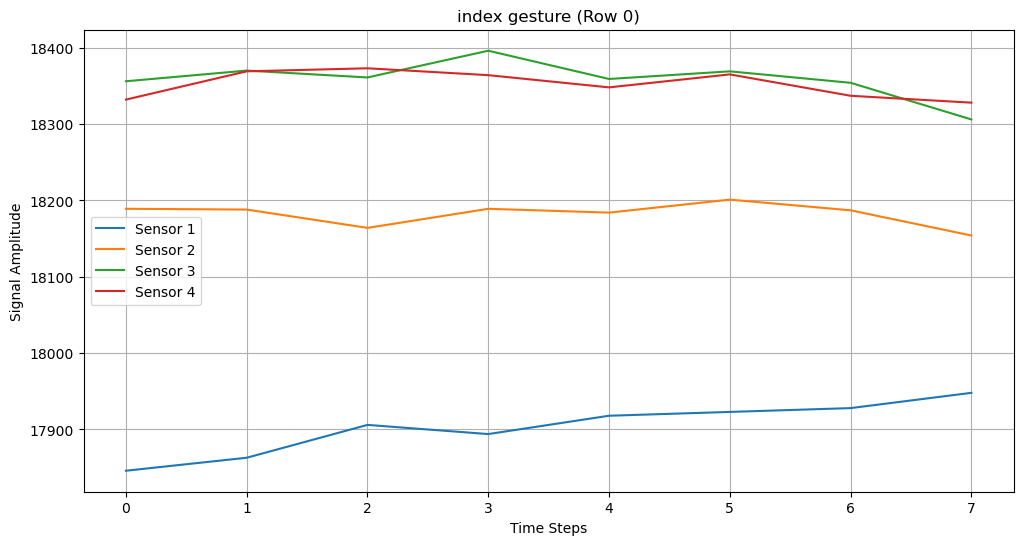

In [127]:
plot_time_signals(concat_dfs[1], row_index=0, title=f'{GESTURES[1]} gesture')

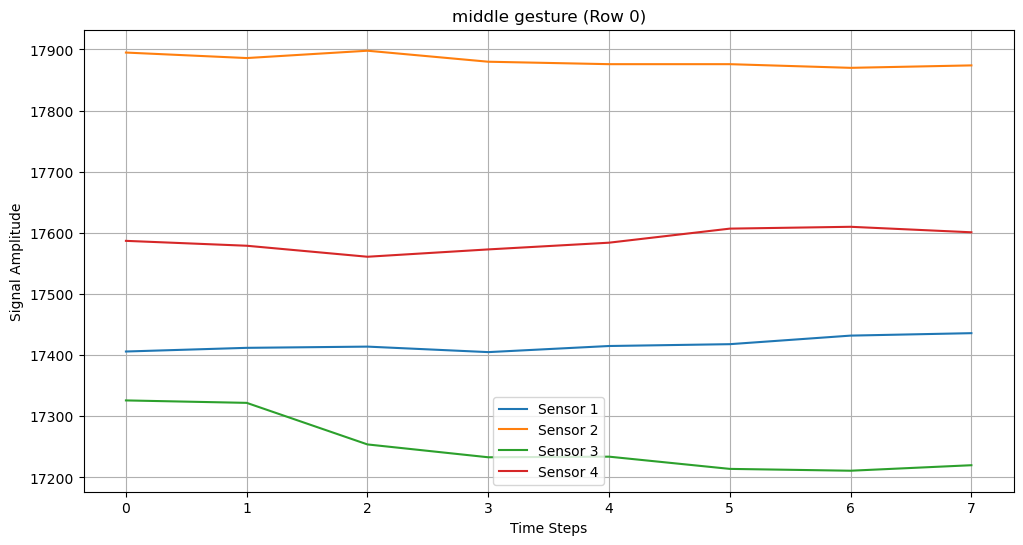

In [128]:
plot_time_signals(concat_dfs[2], row_index=0, title=f'{GESTURES[2]} gesture')

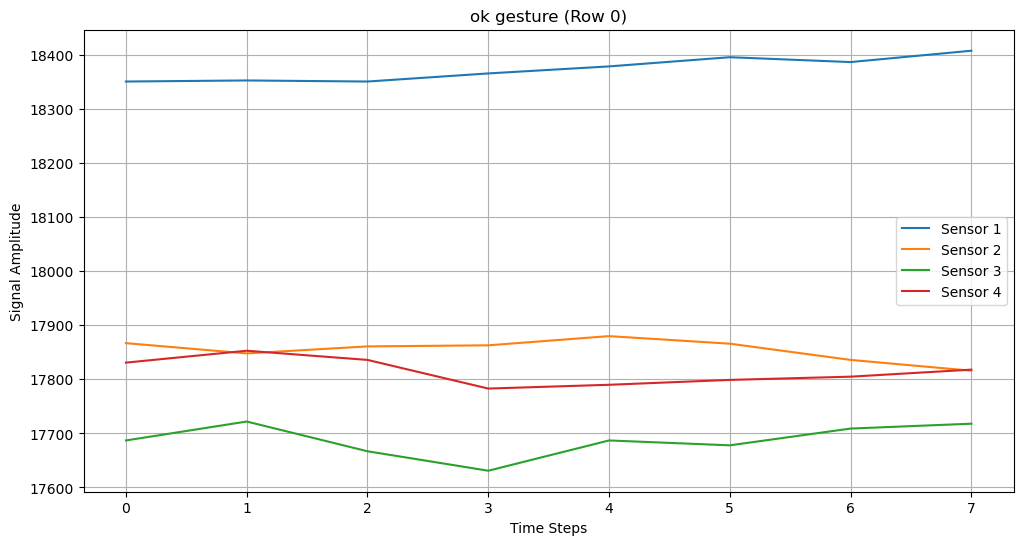

In [129]:
plot_time_signals(concat_dfs[3], row_index=0, title=f'{GESTURES[3]} gesture')

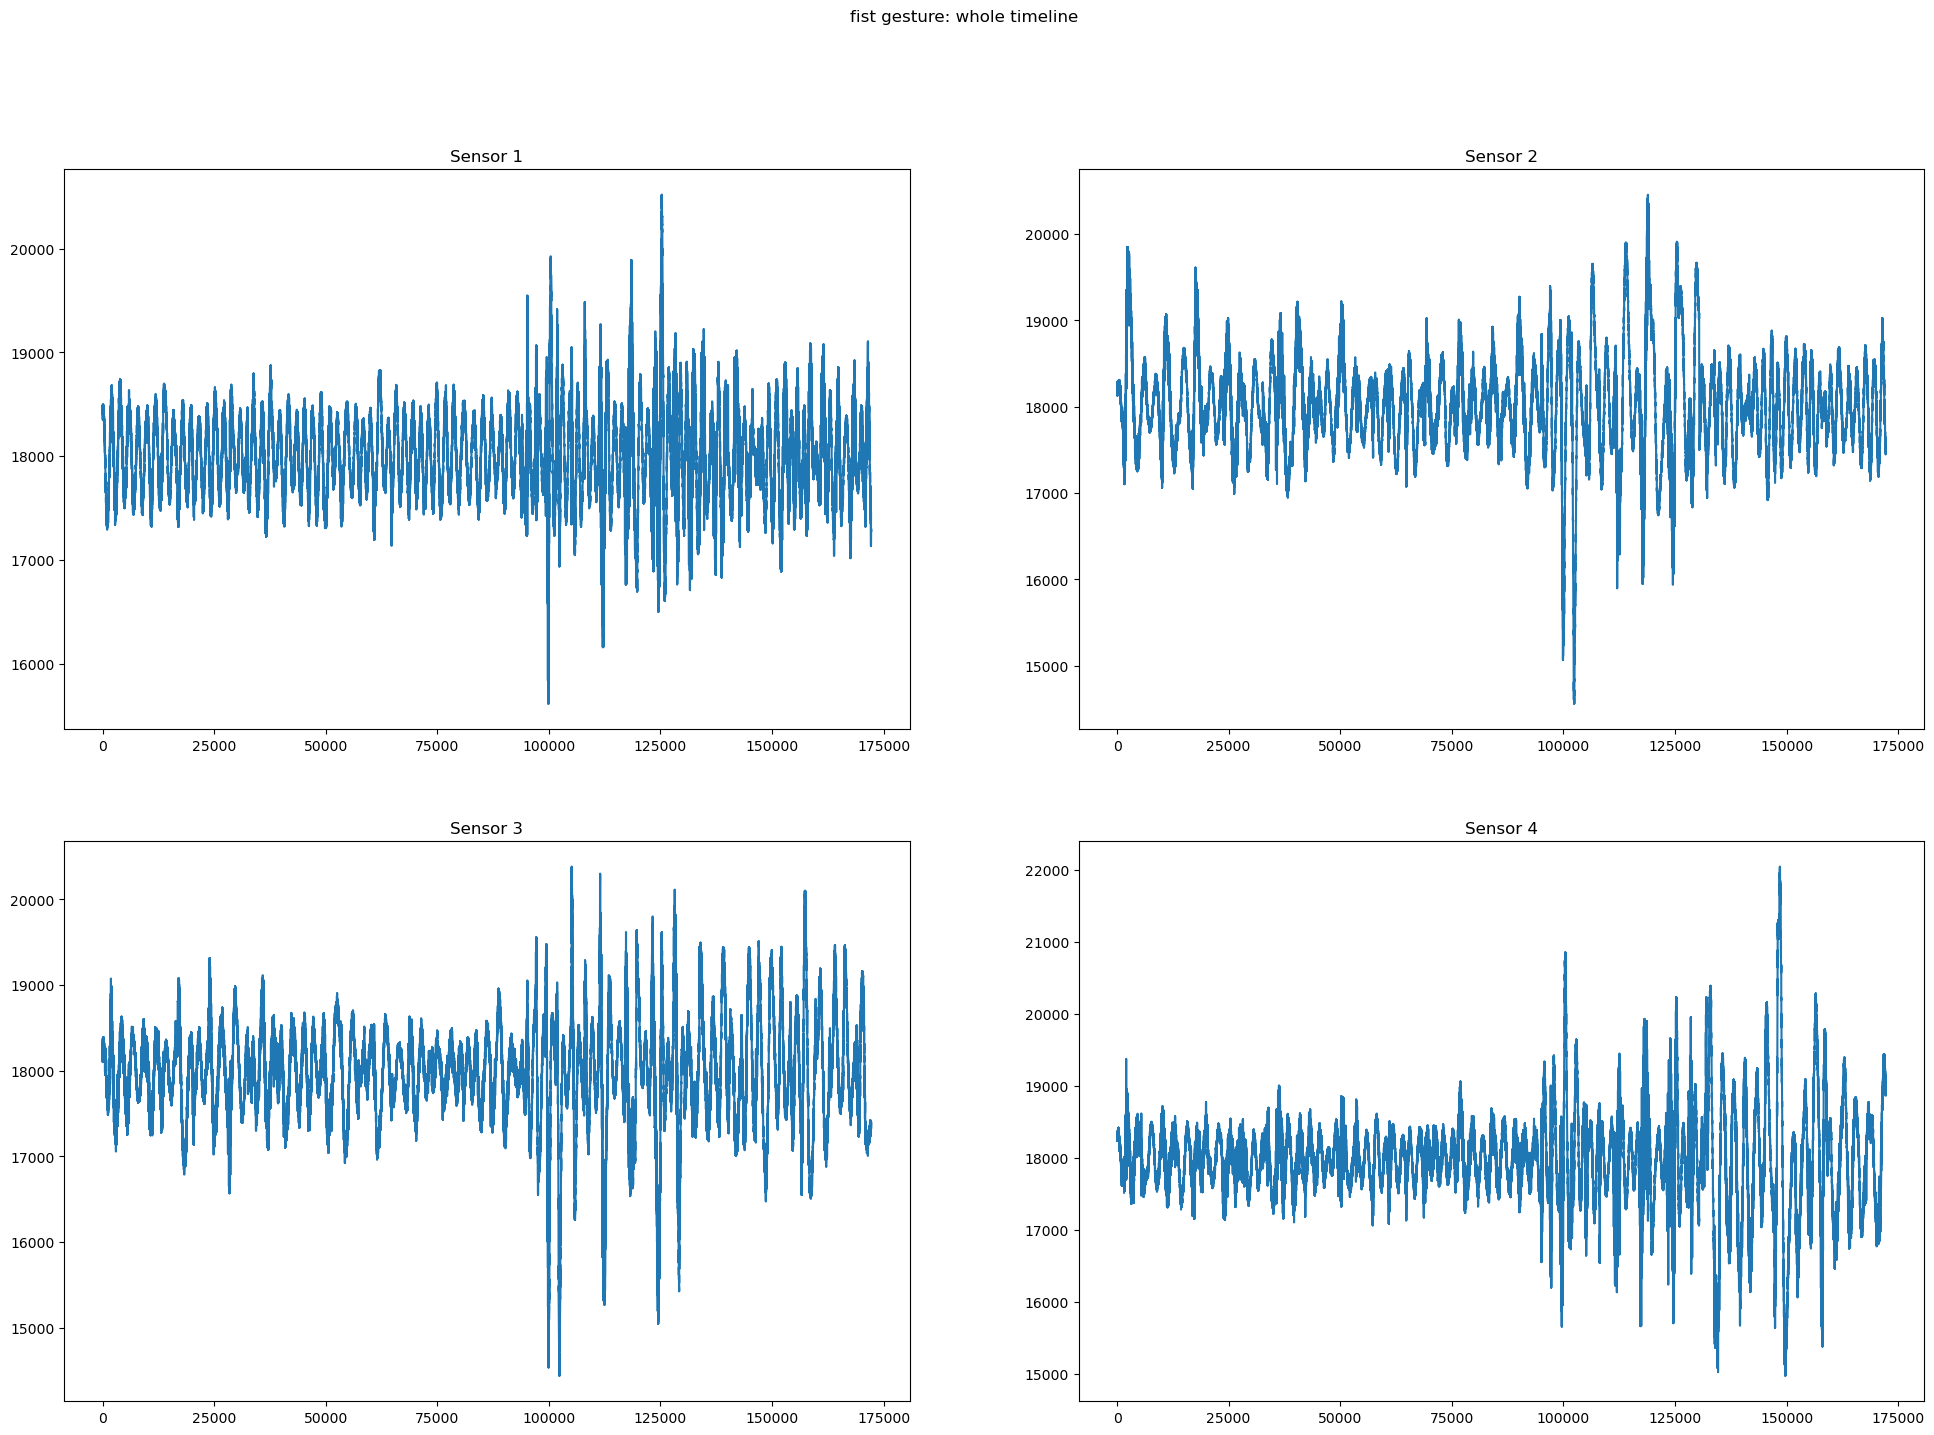

/tmp/ipykernel_5486/3058859634.py:126: RuntimeWarning: divide by zero encountered in divide
  snr = 10 * np.log10(power_signal / self.baseline_noise[sensor_num])


Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


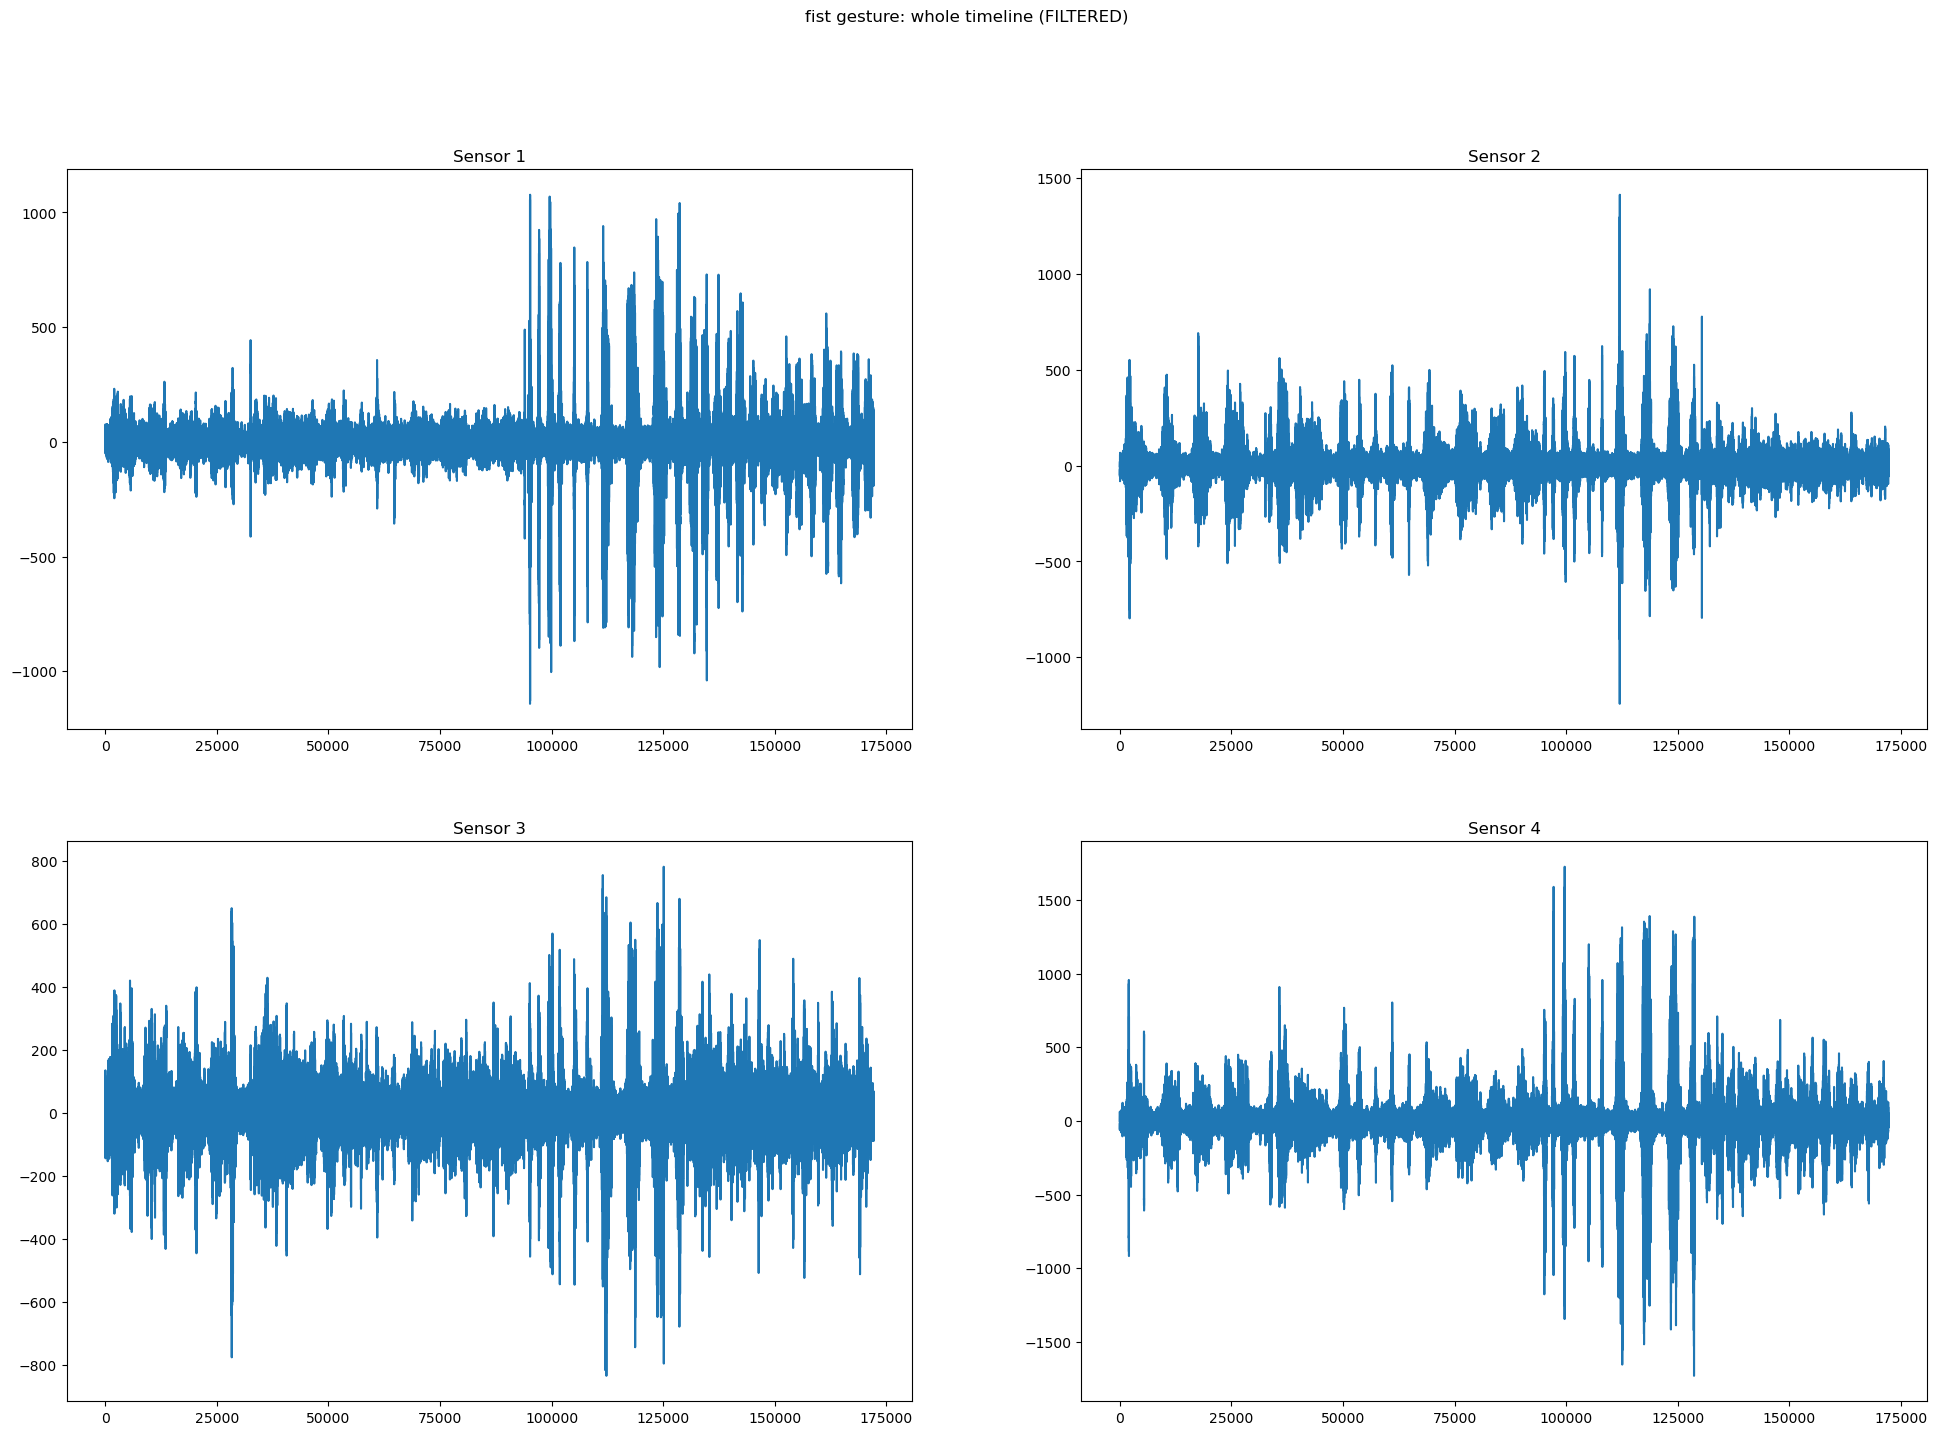

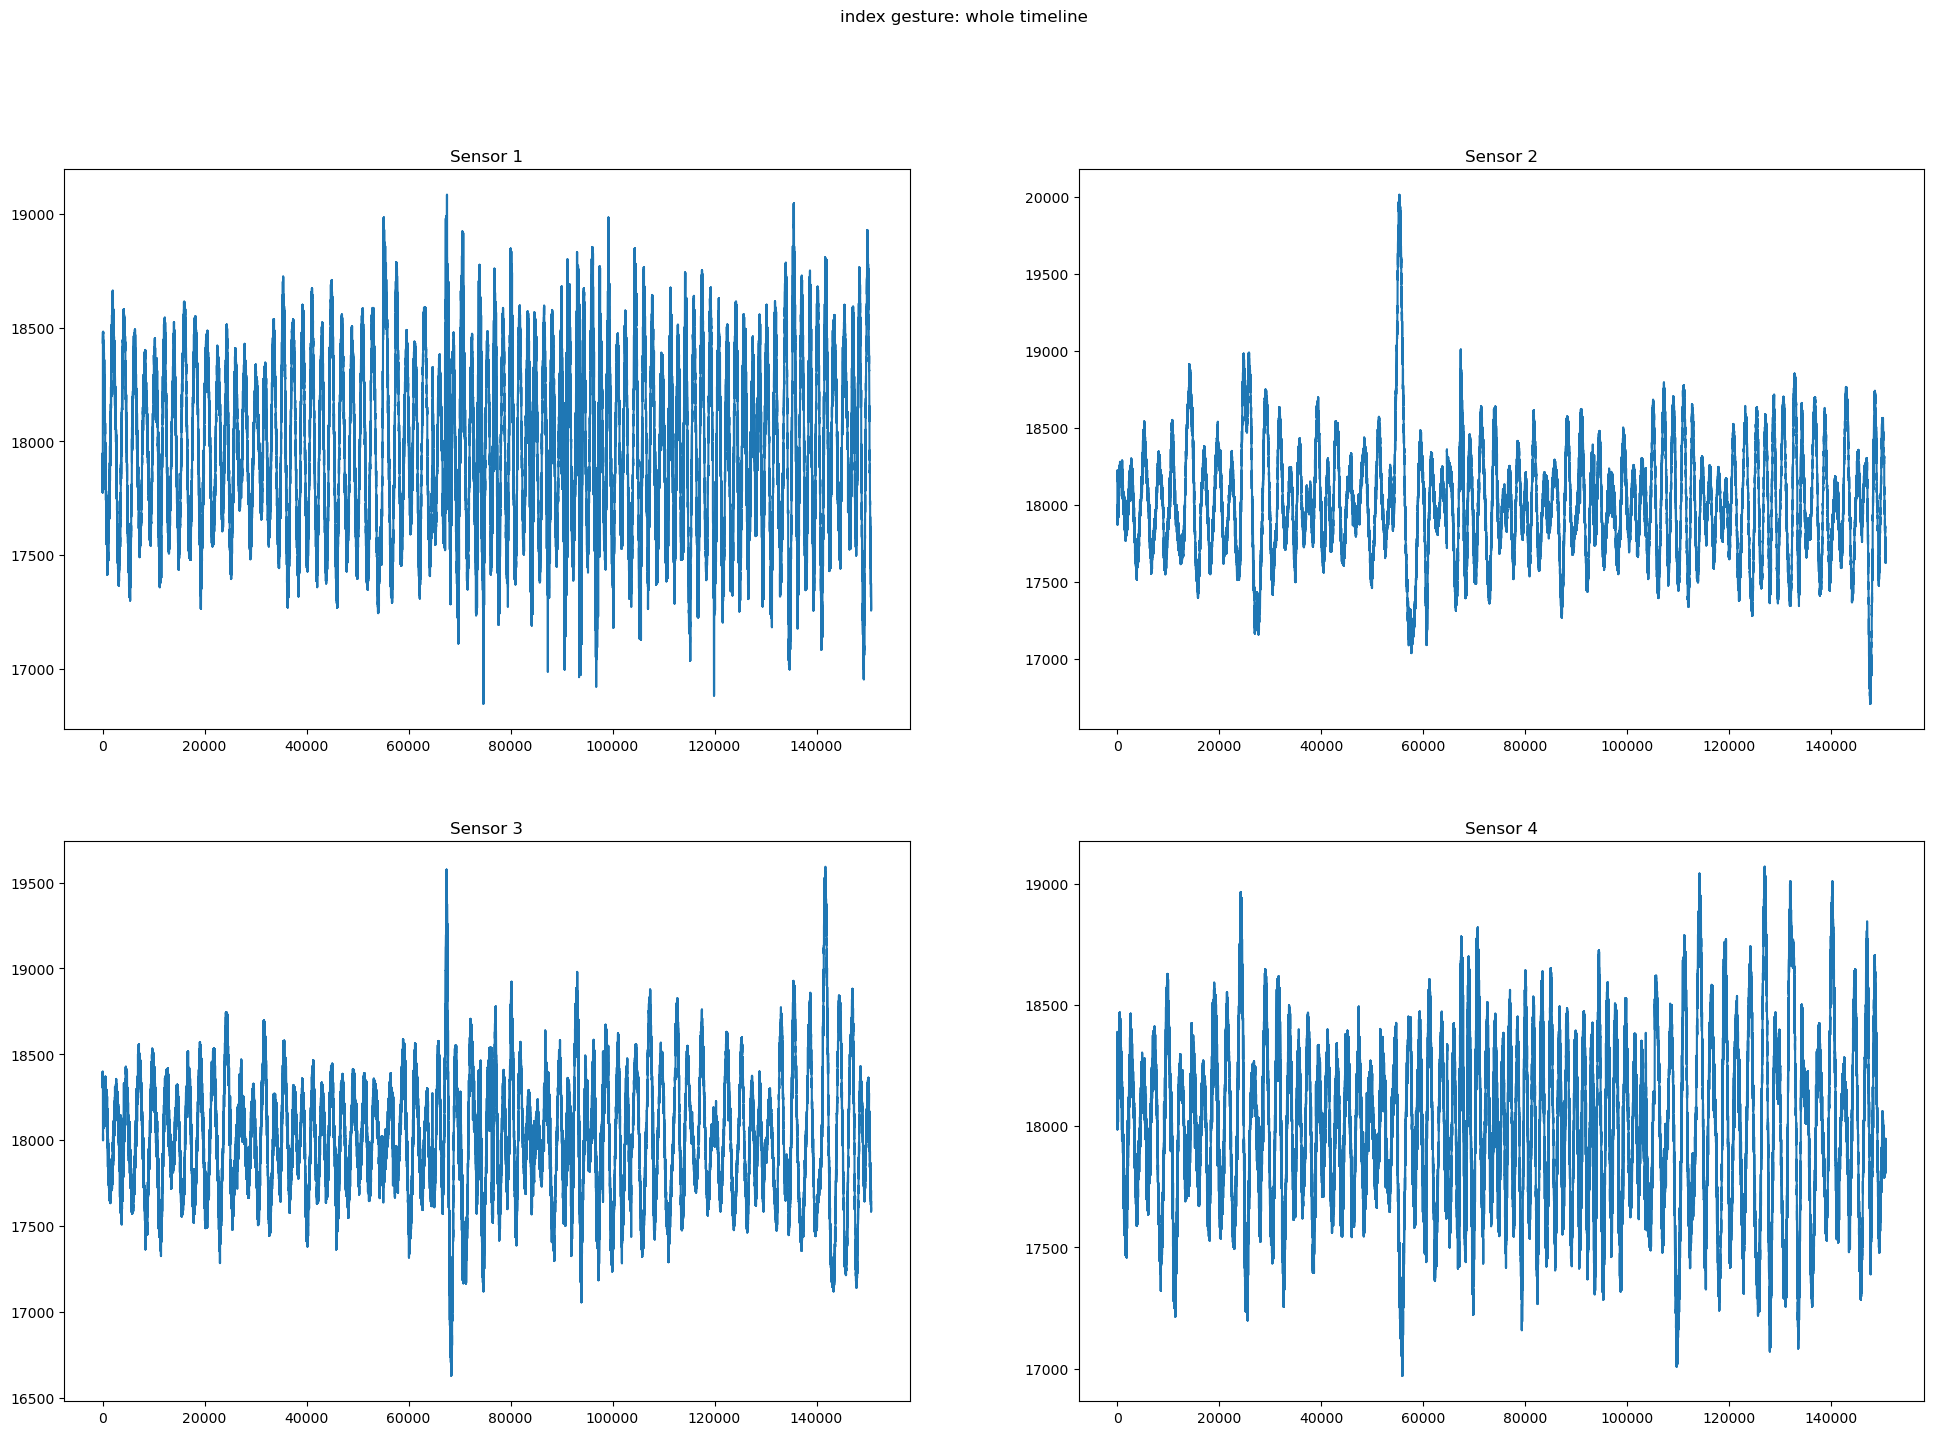

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


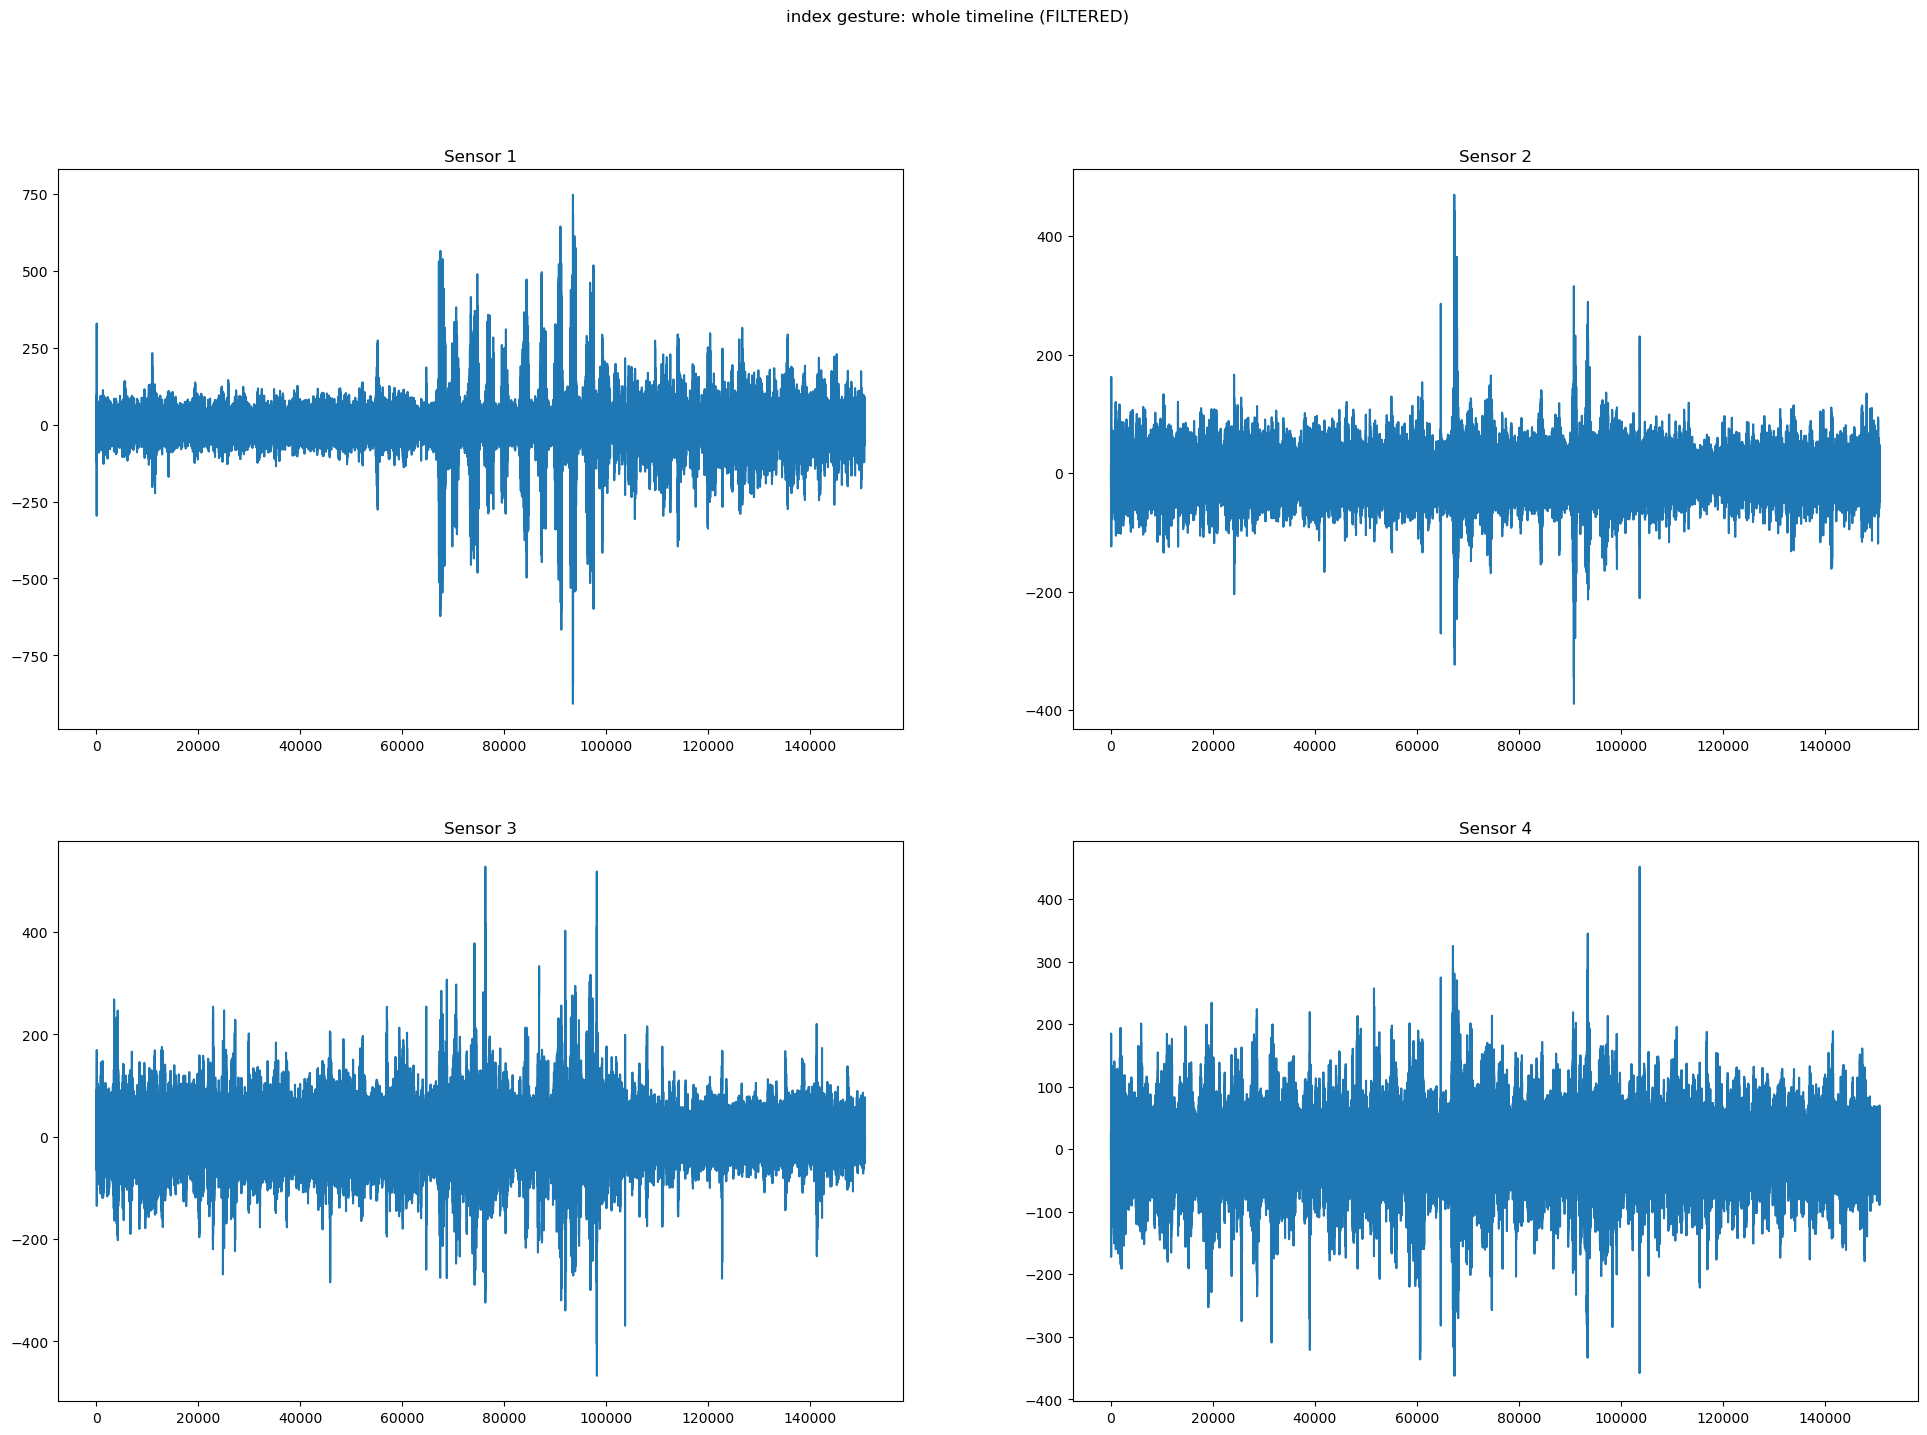

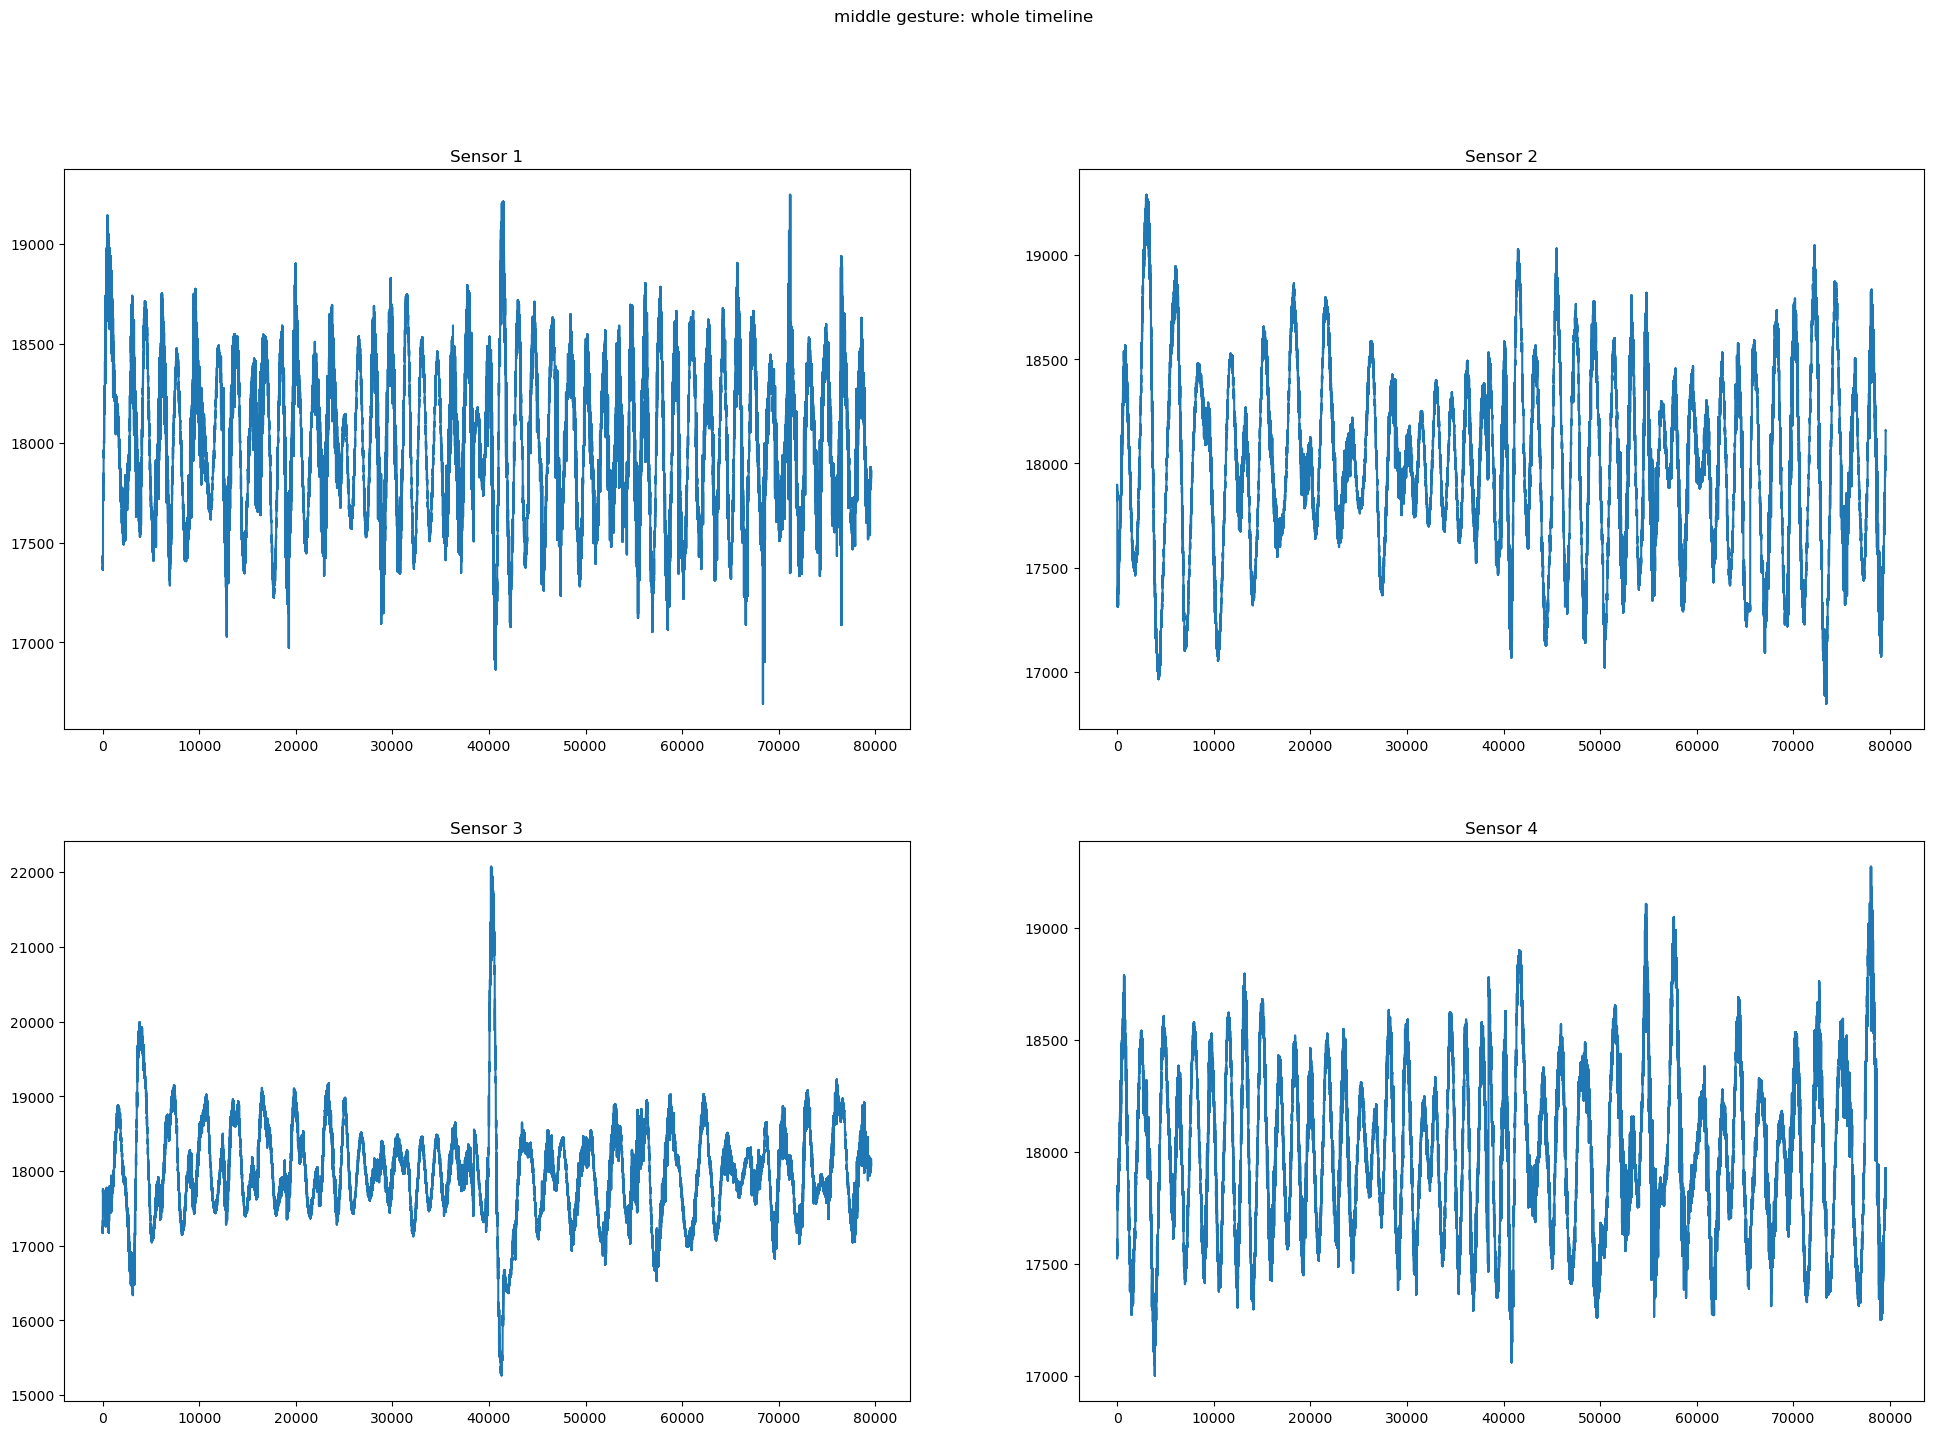

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


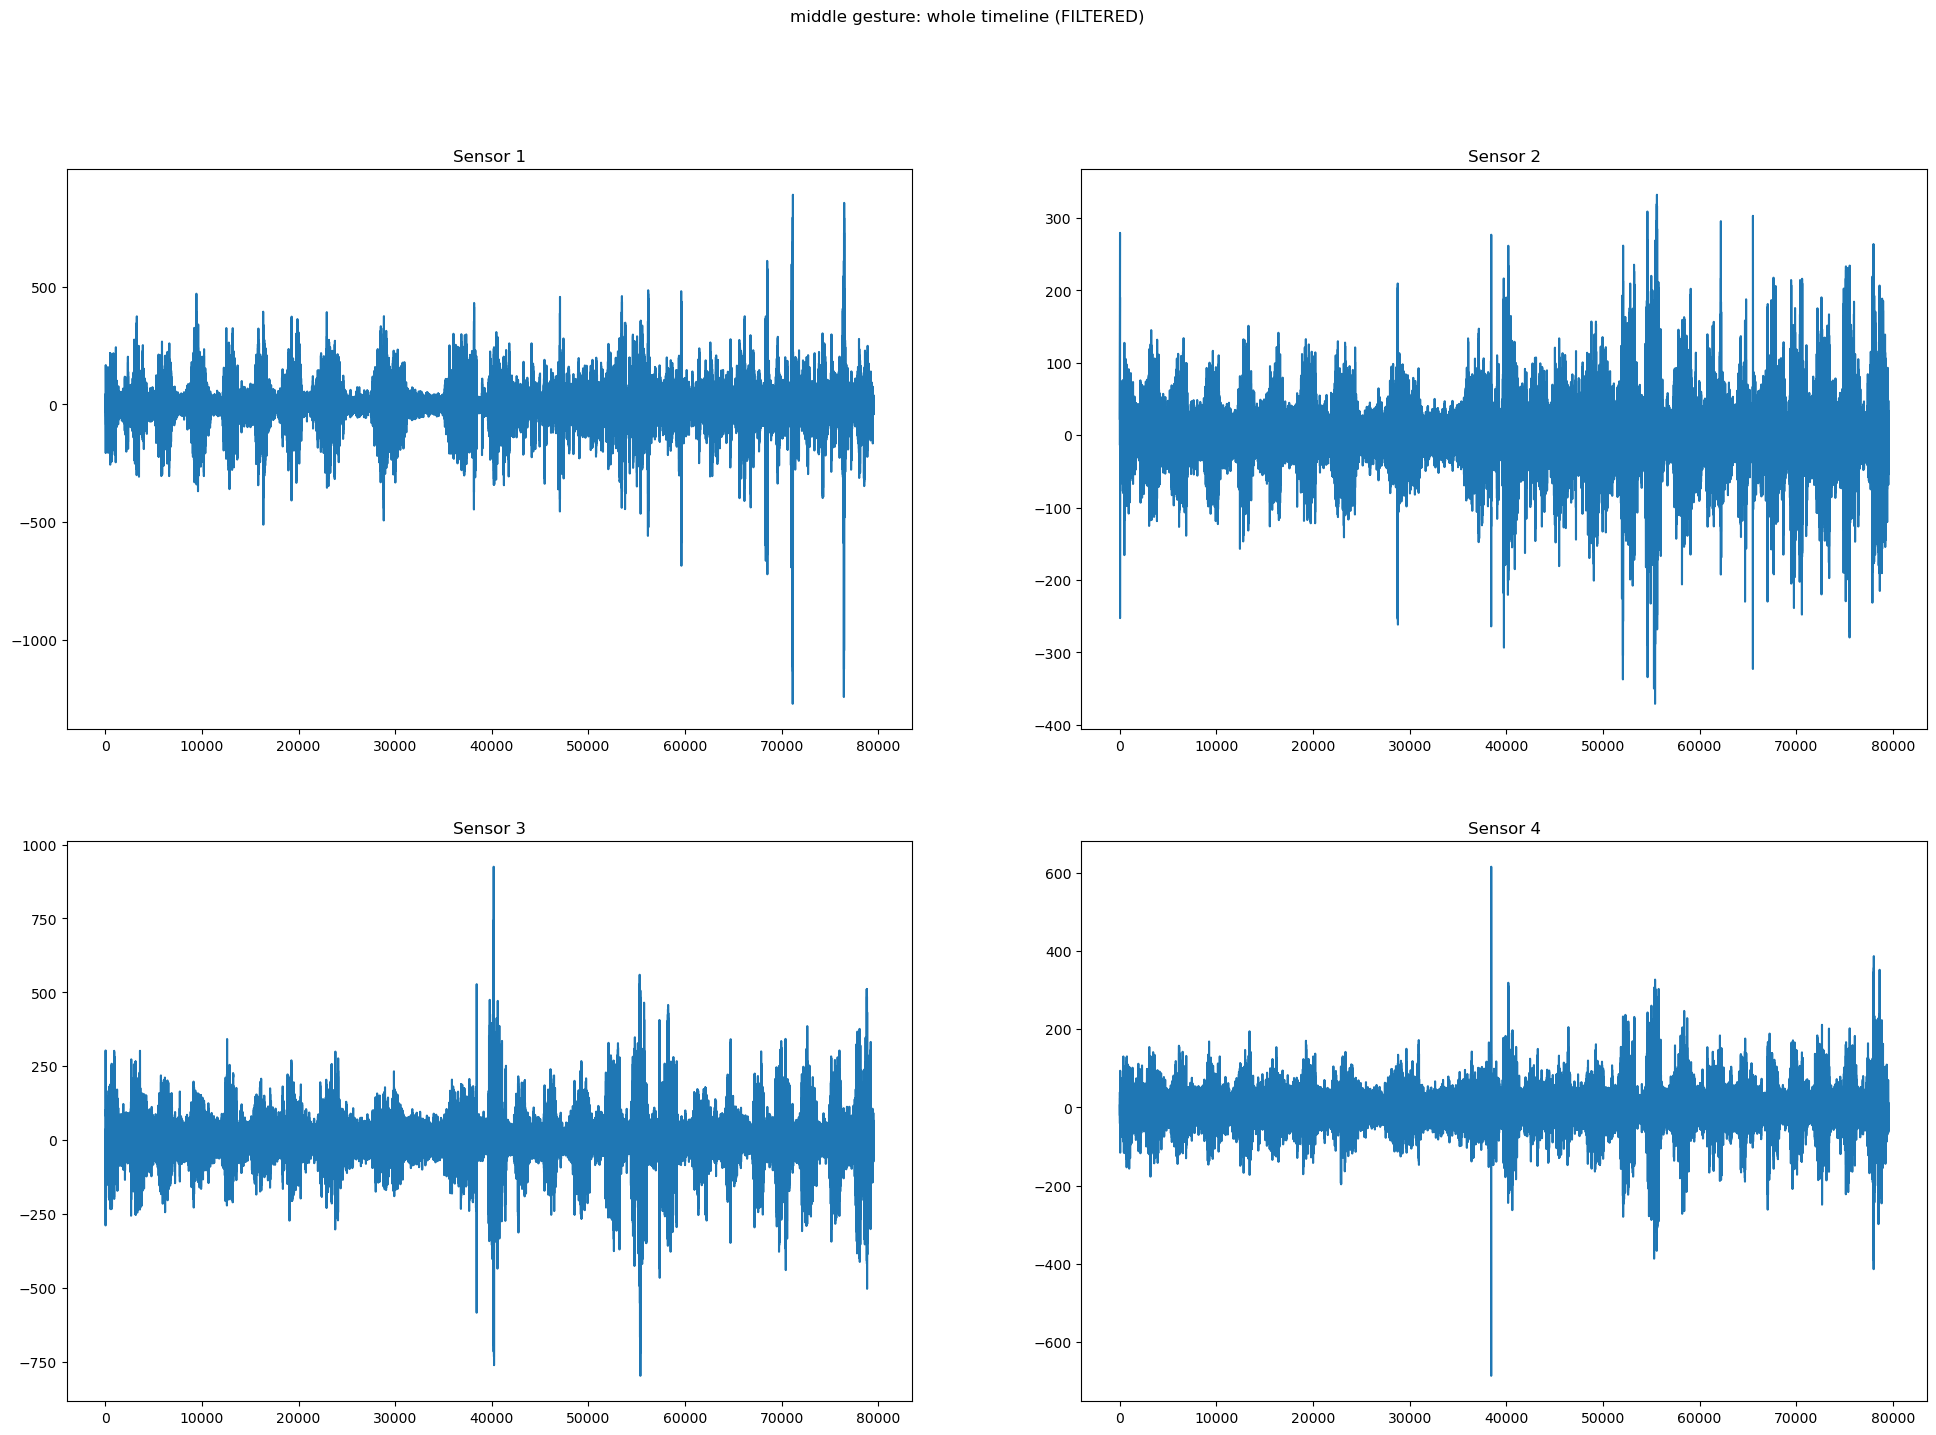

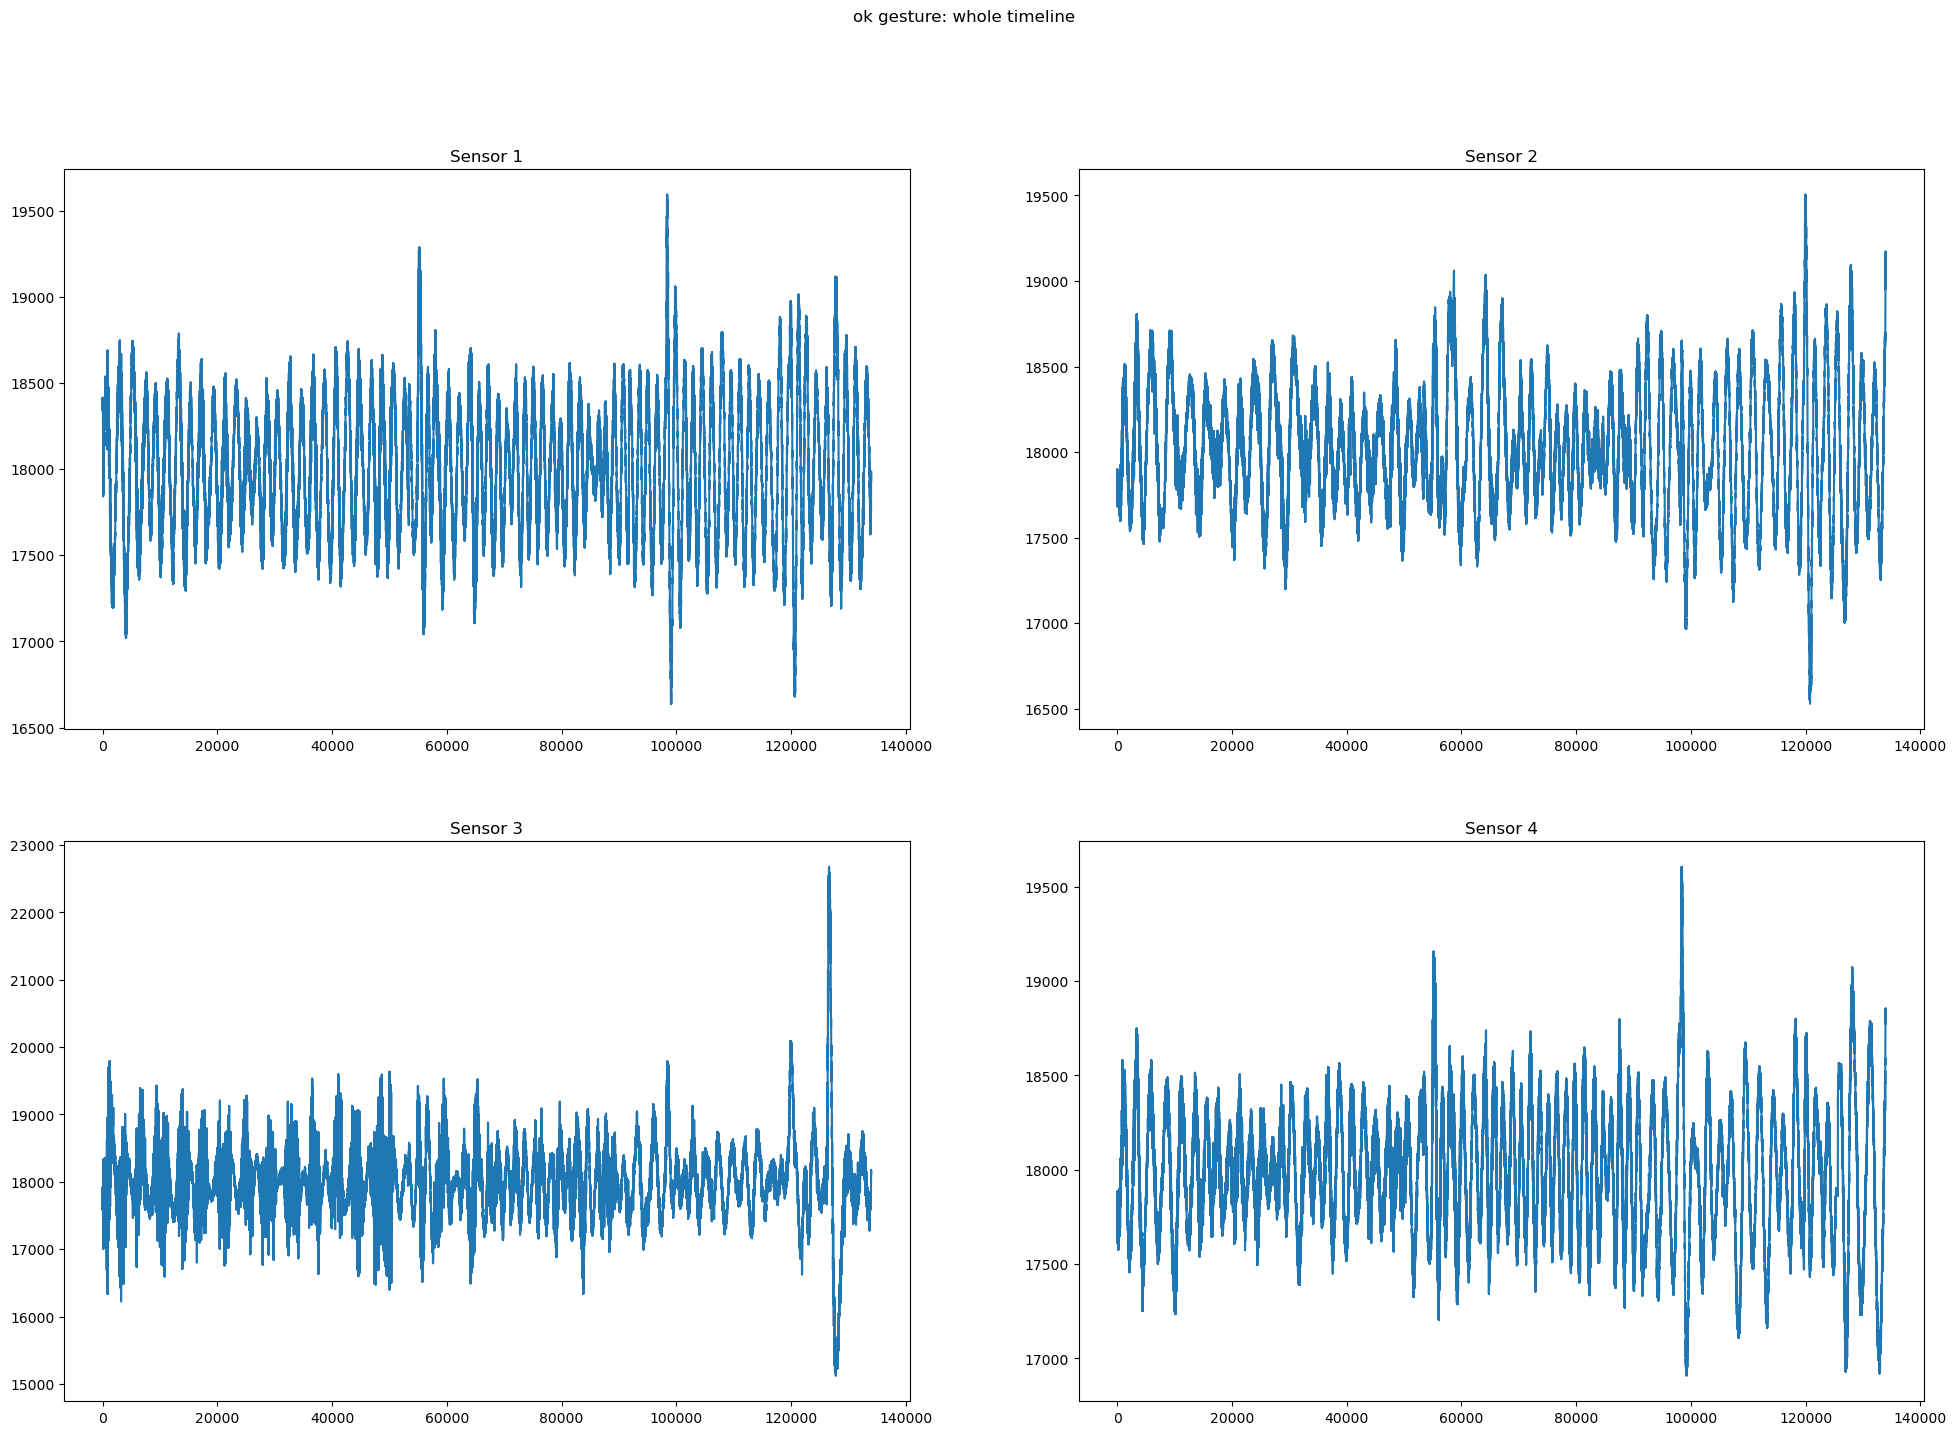

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


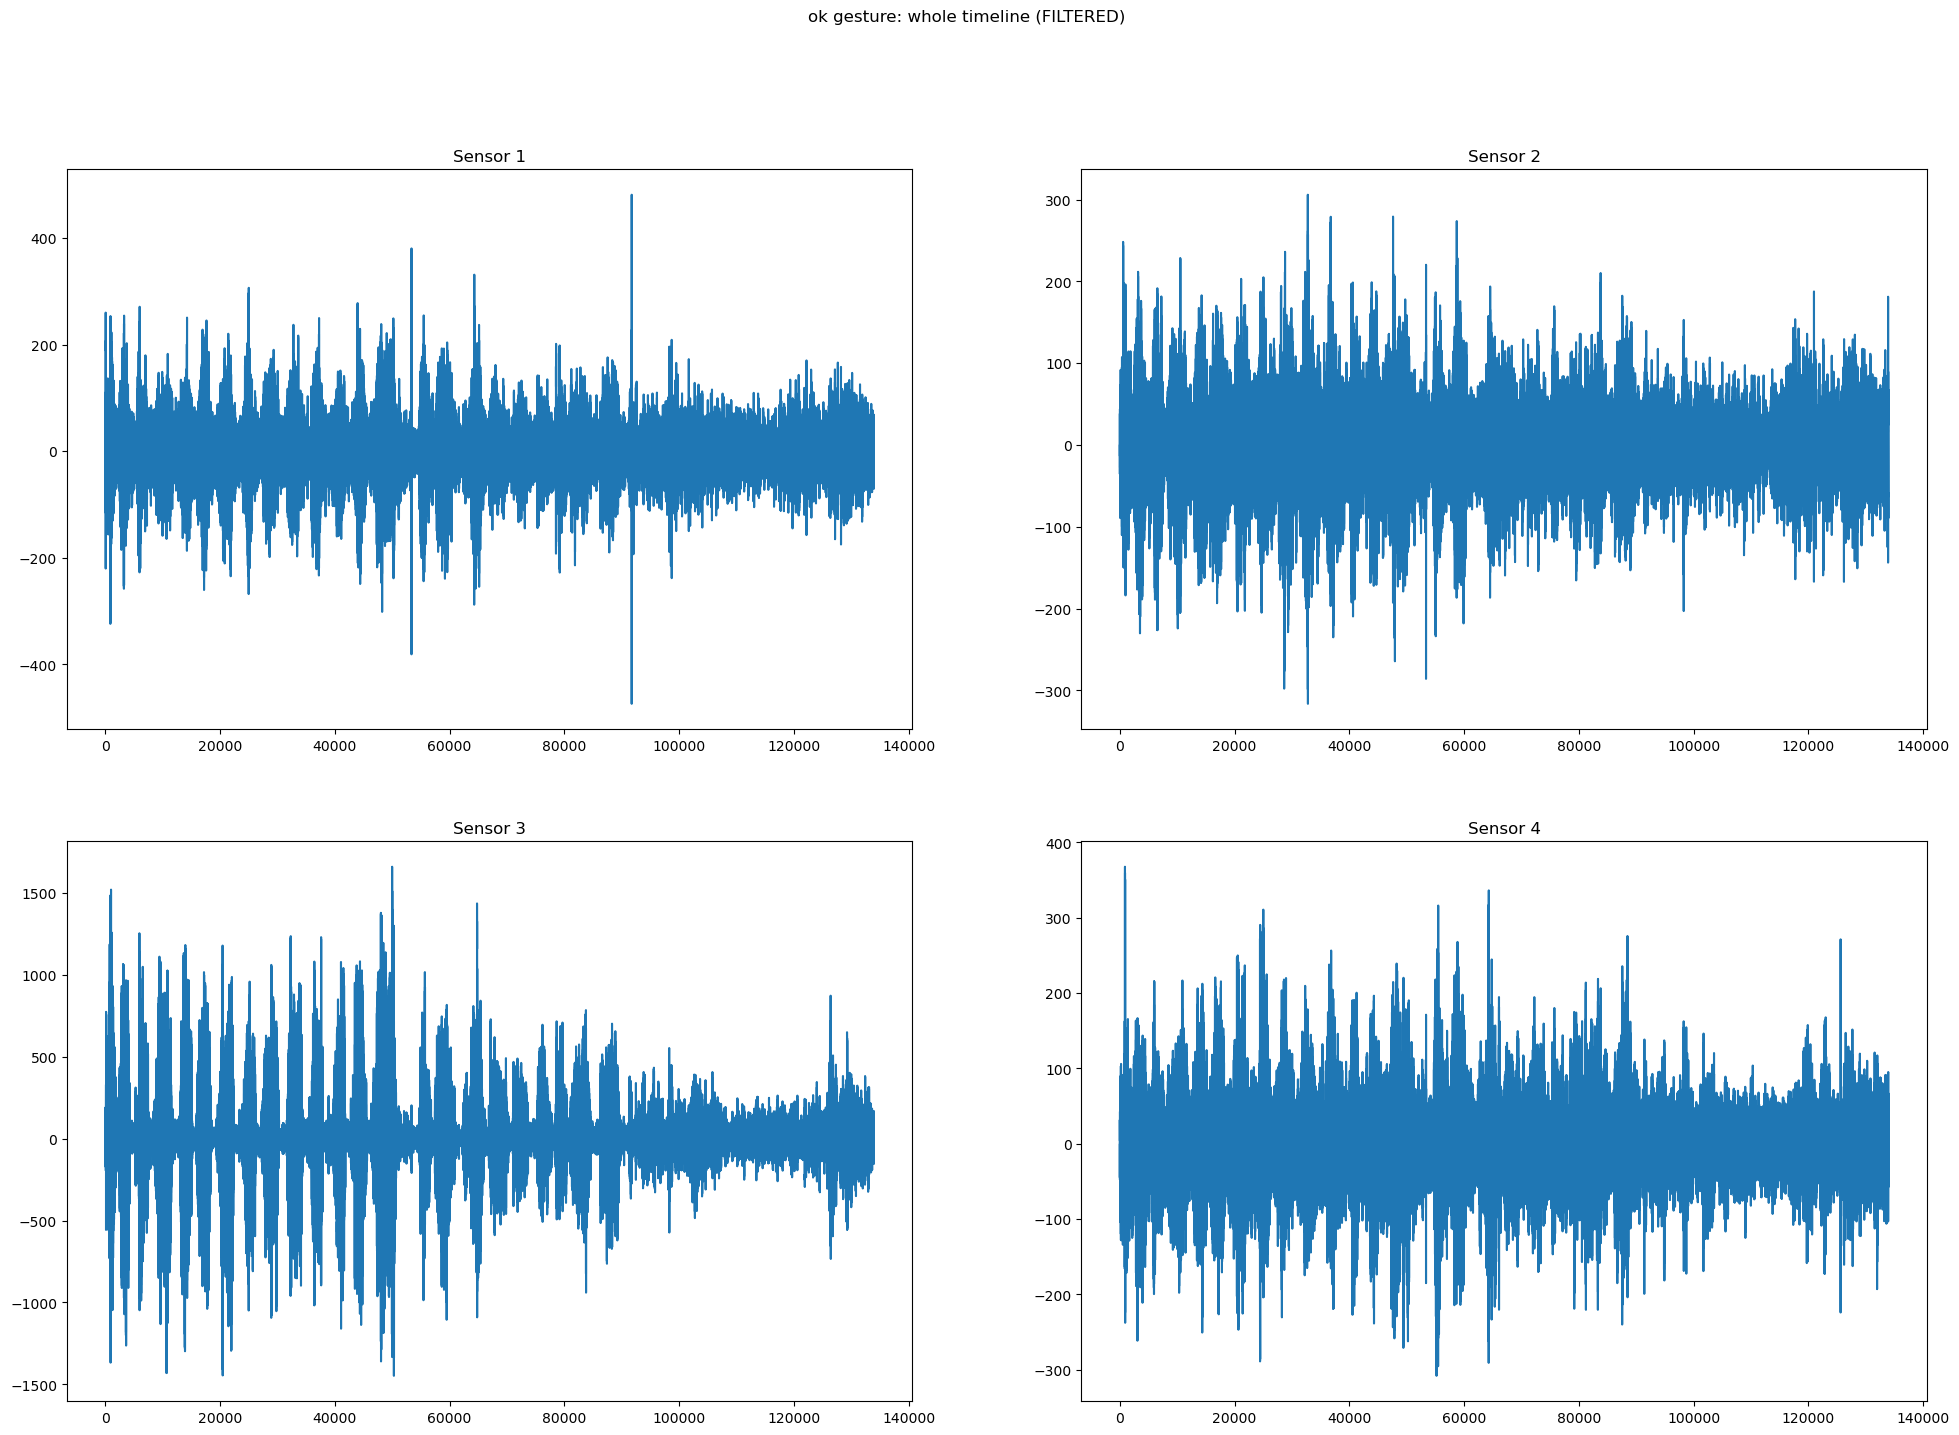

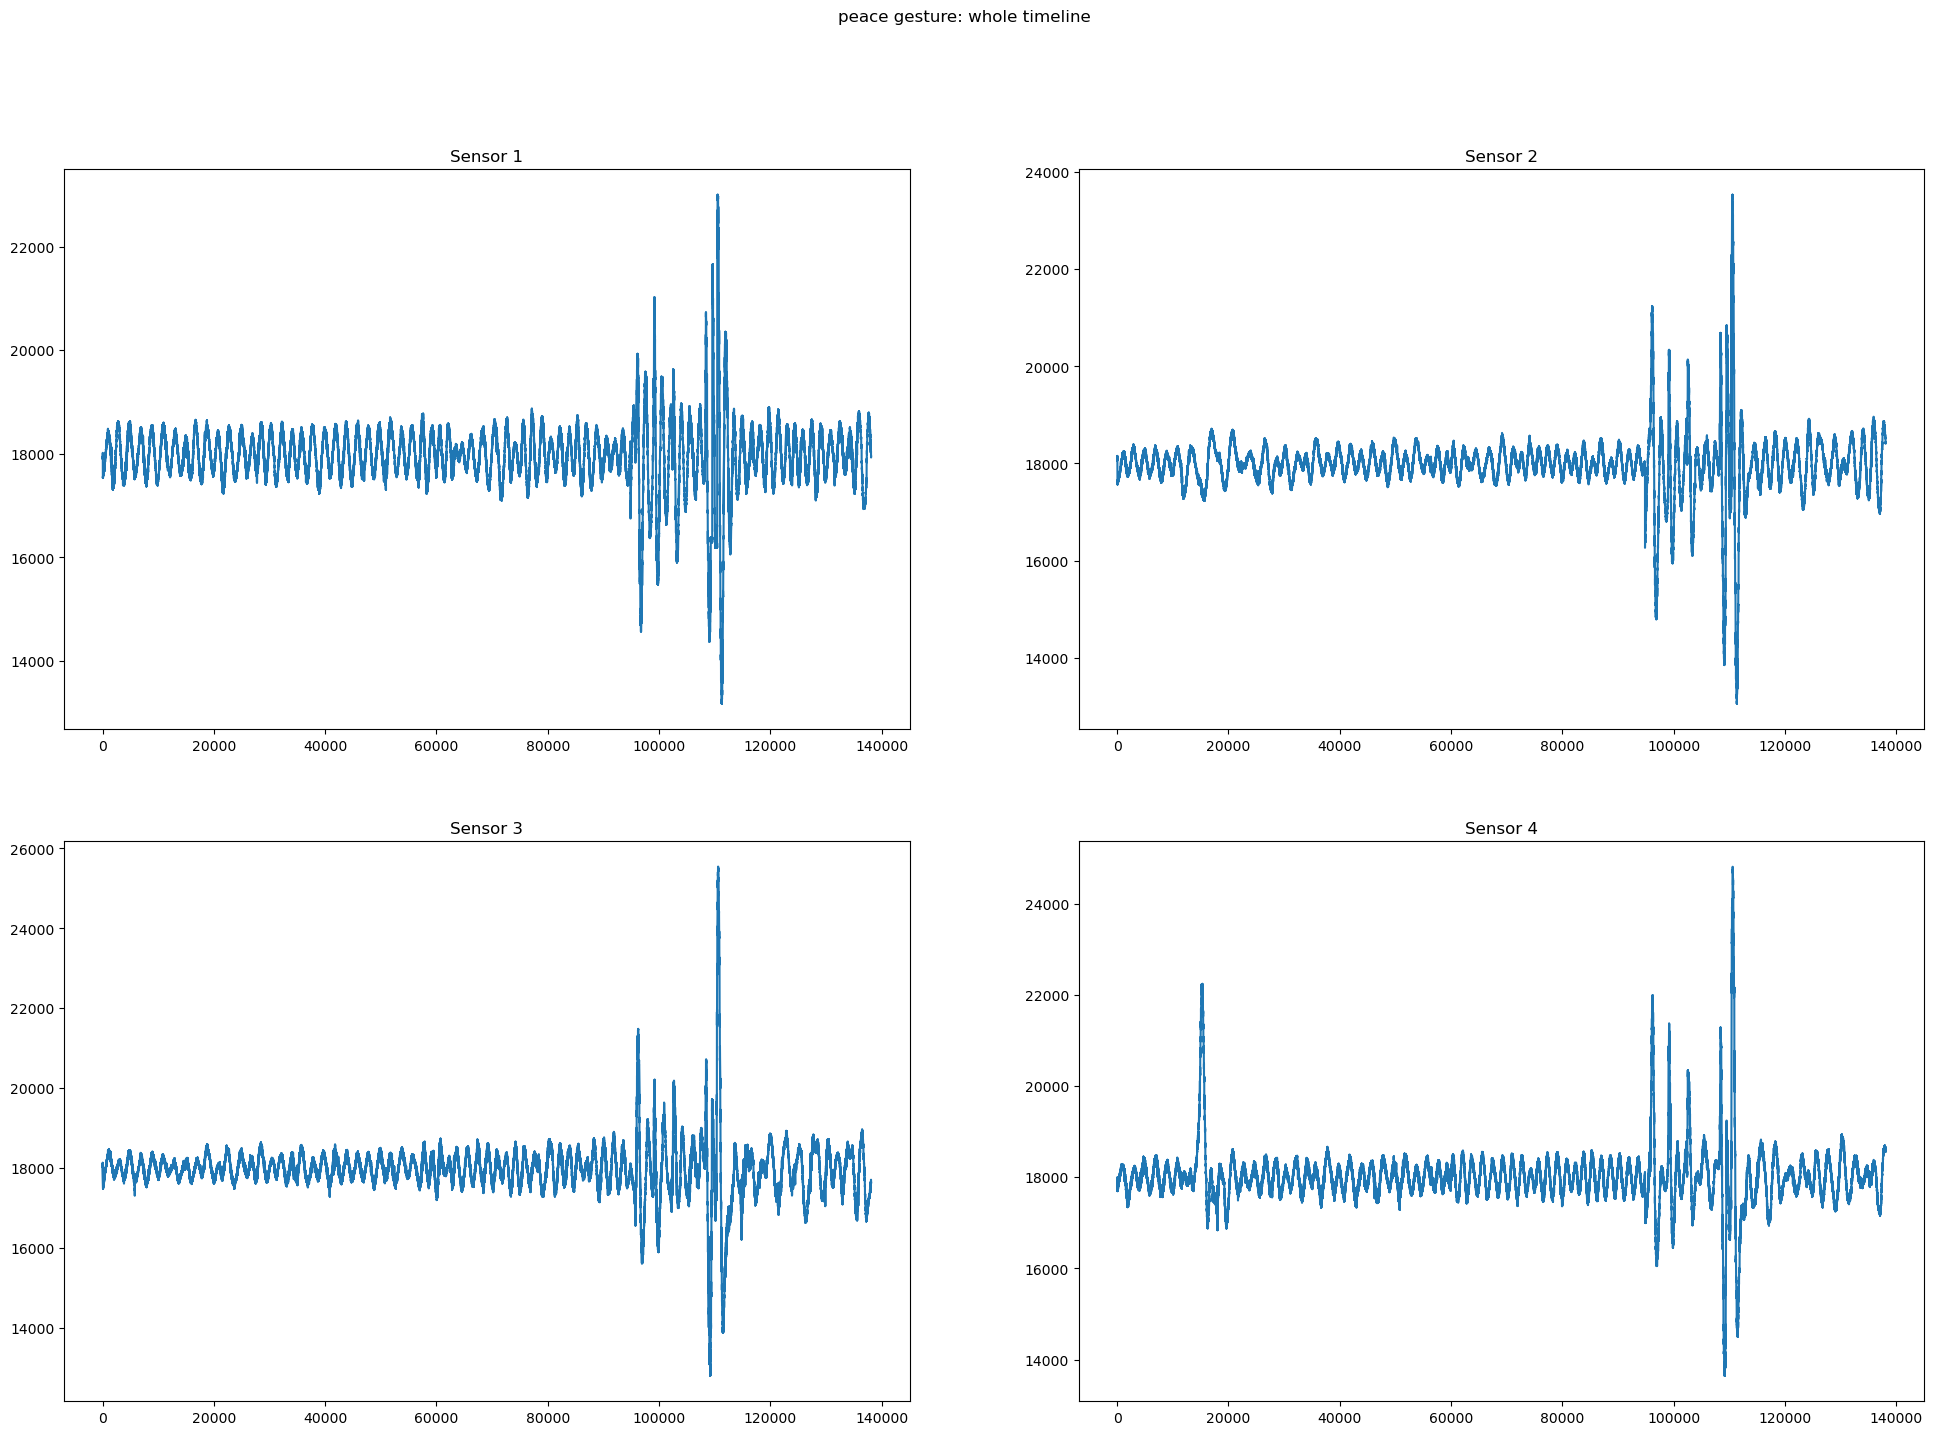

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


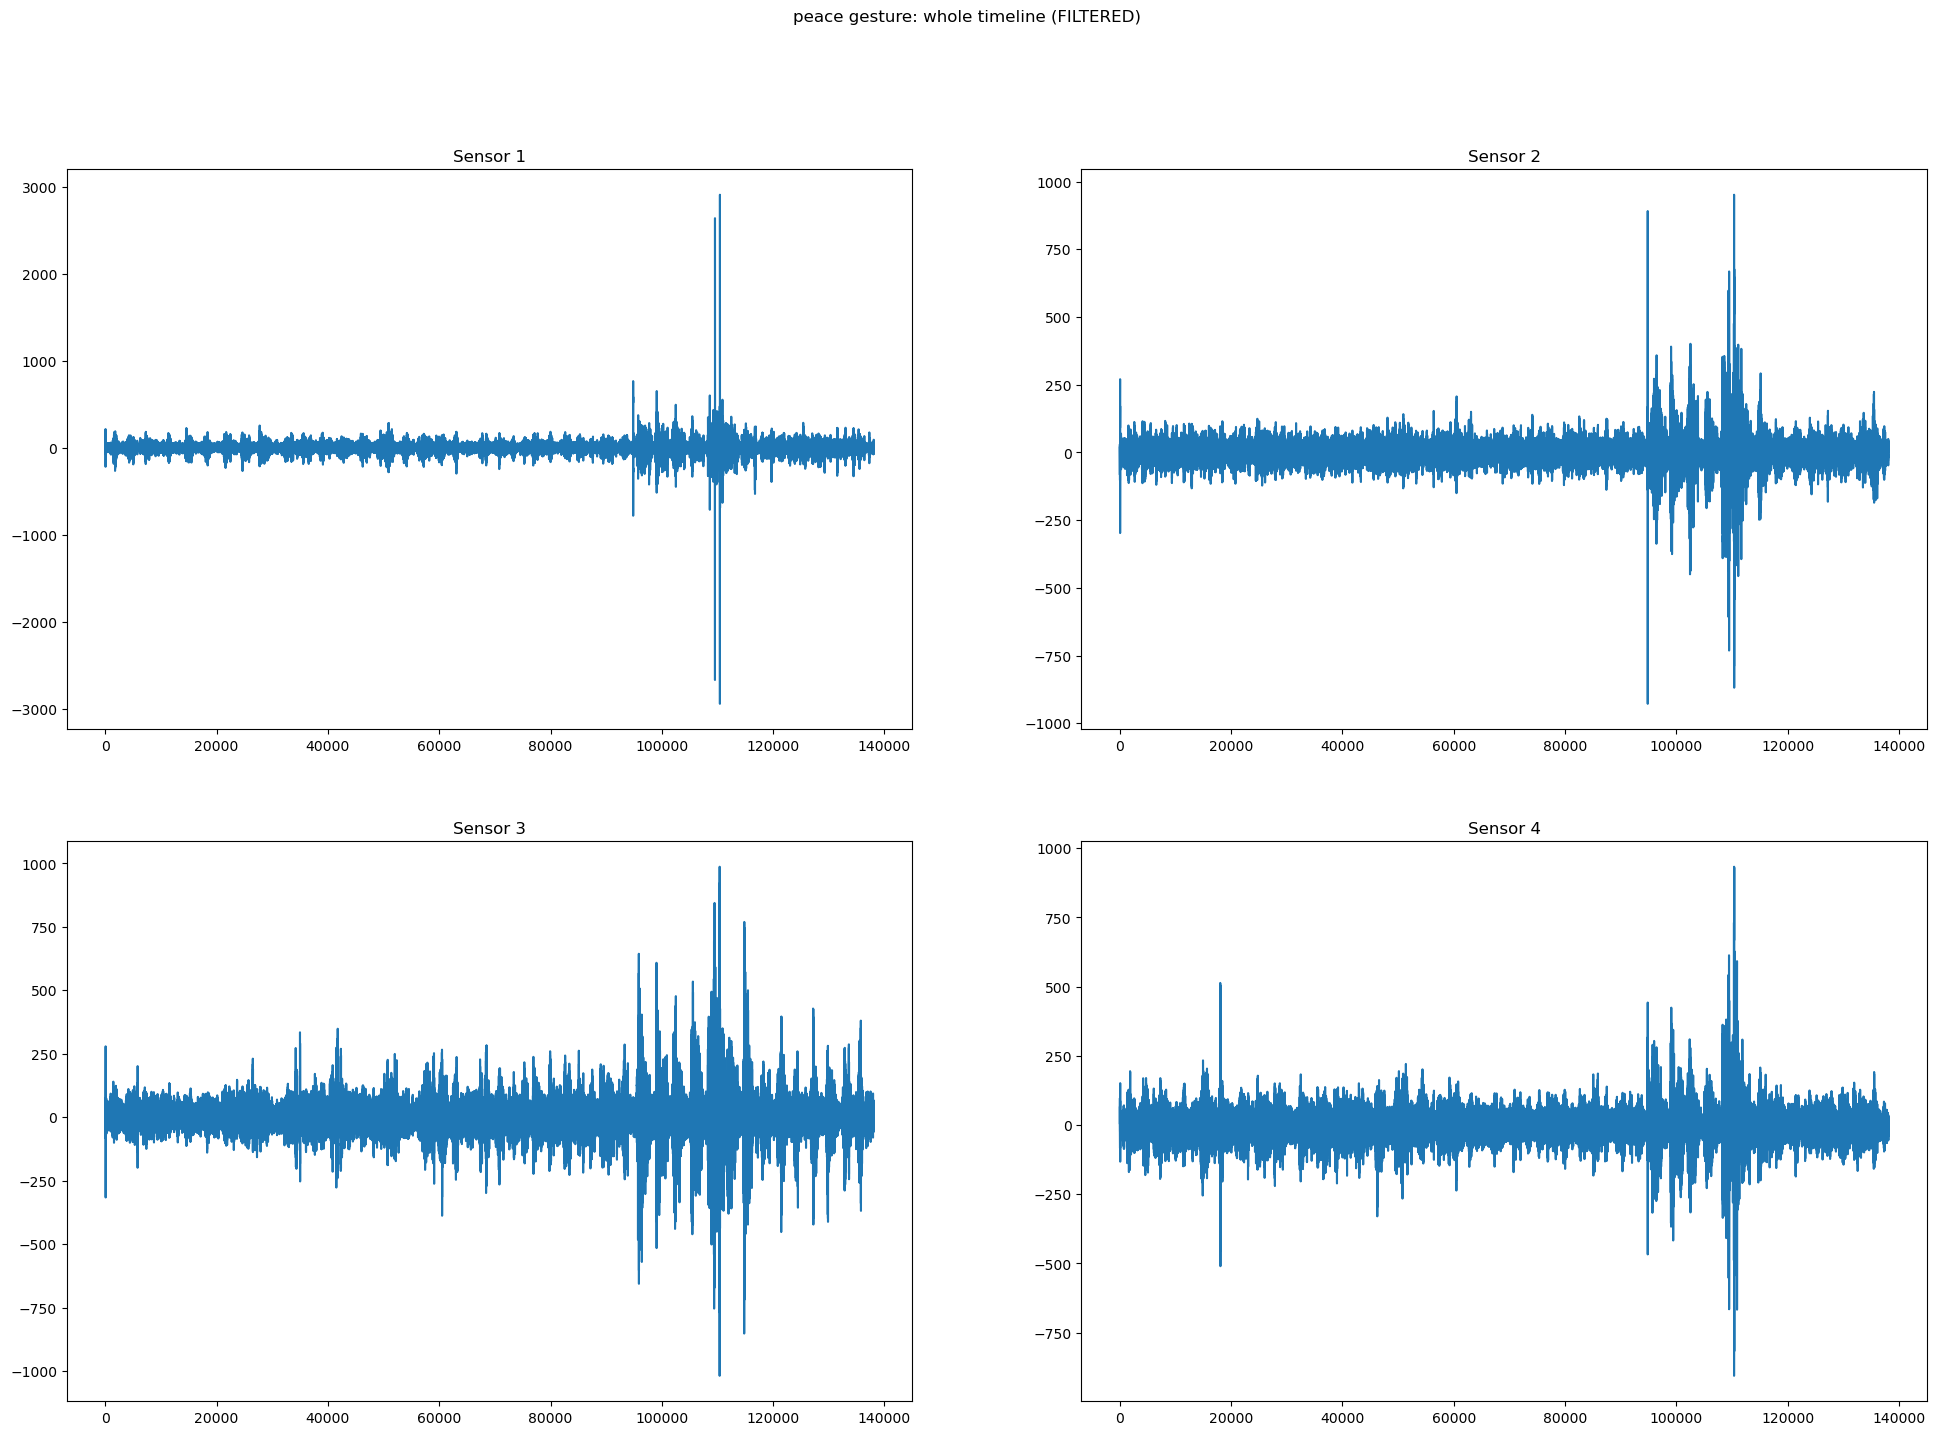

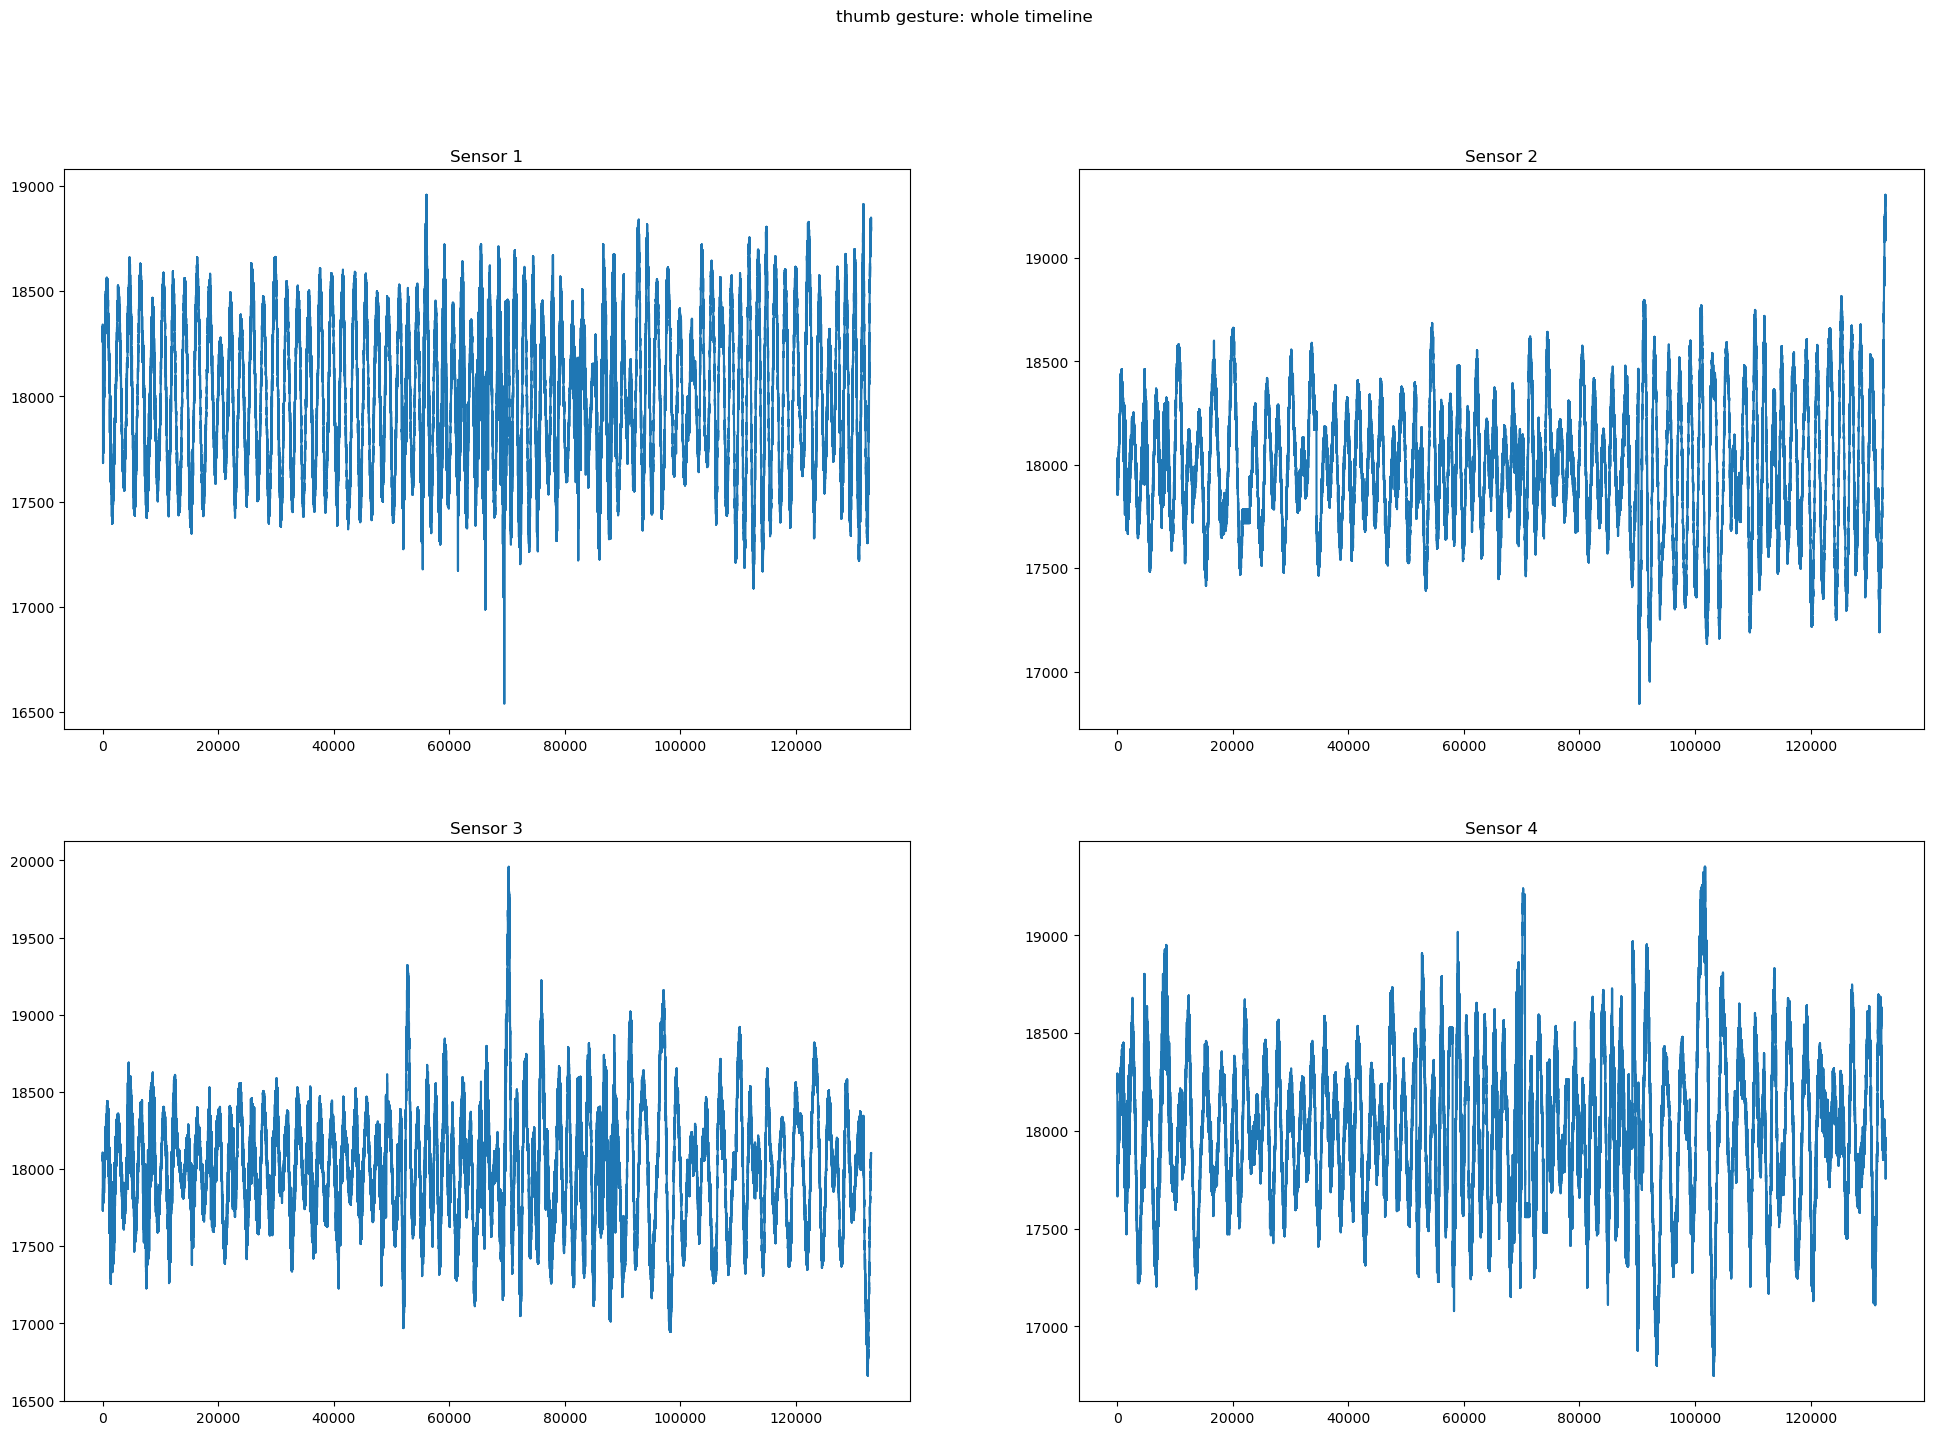

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


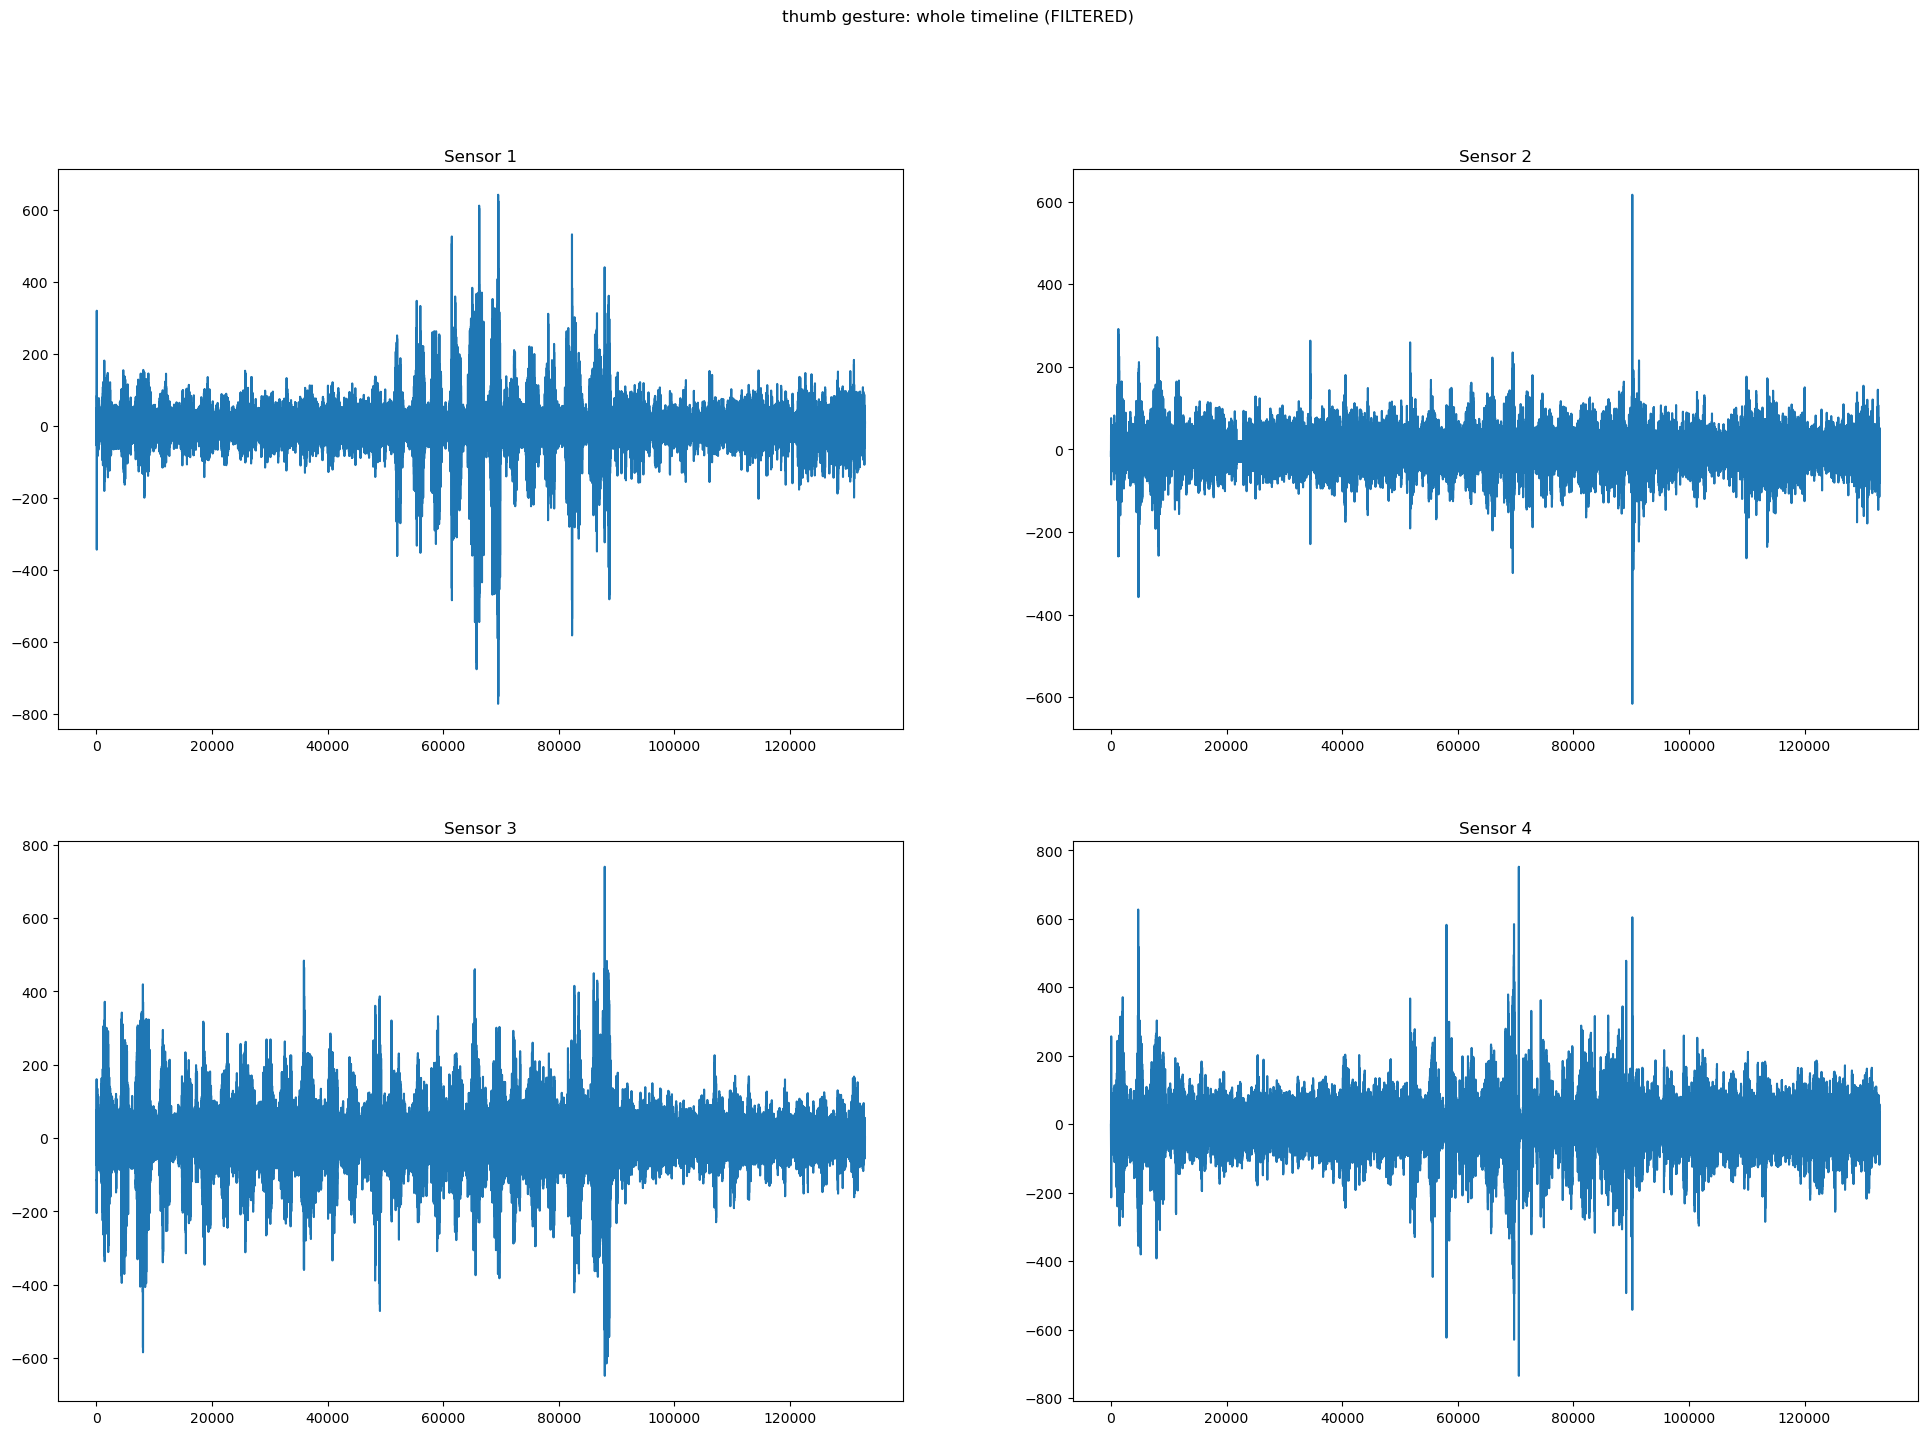

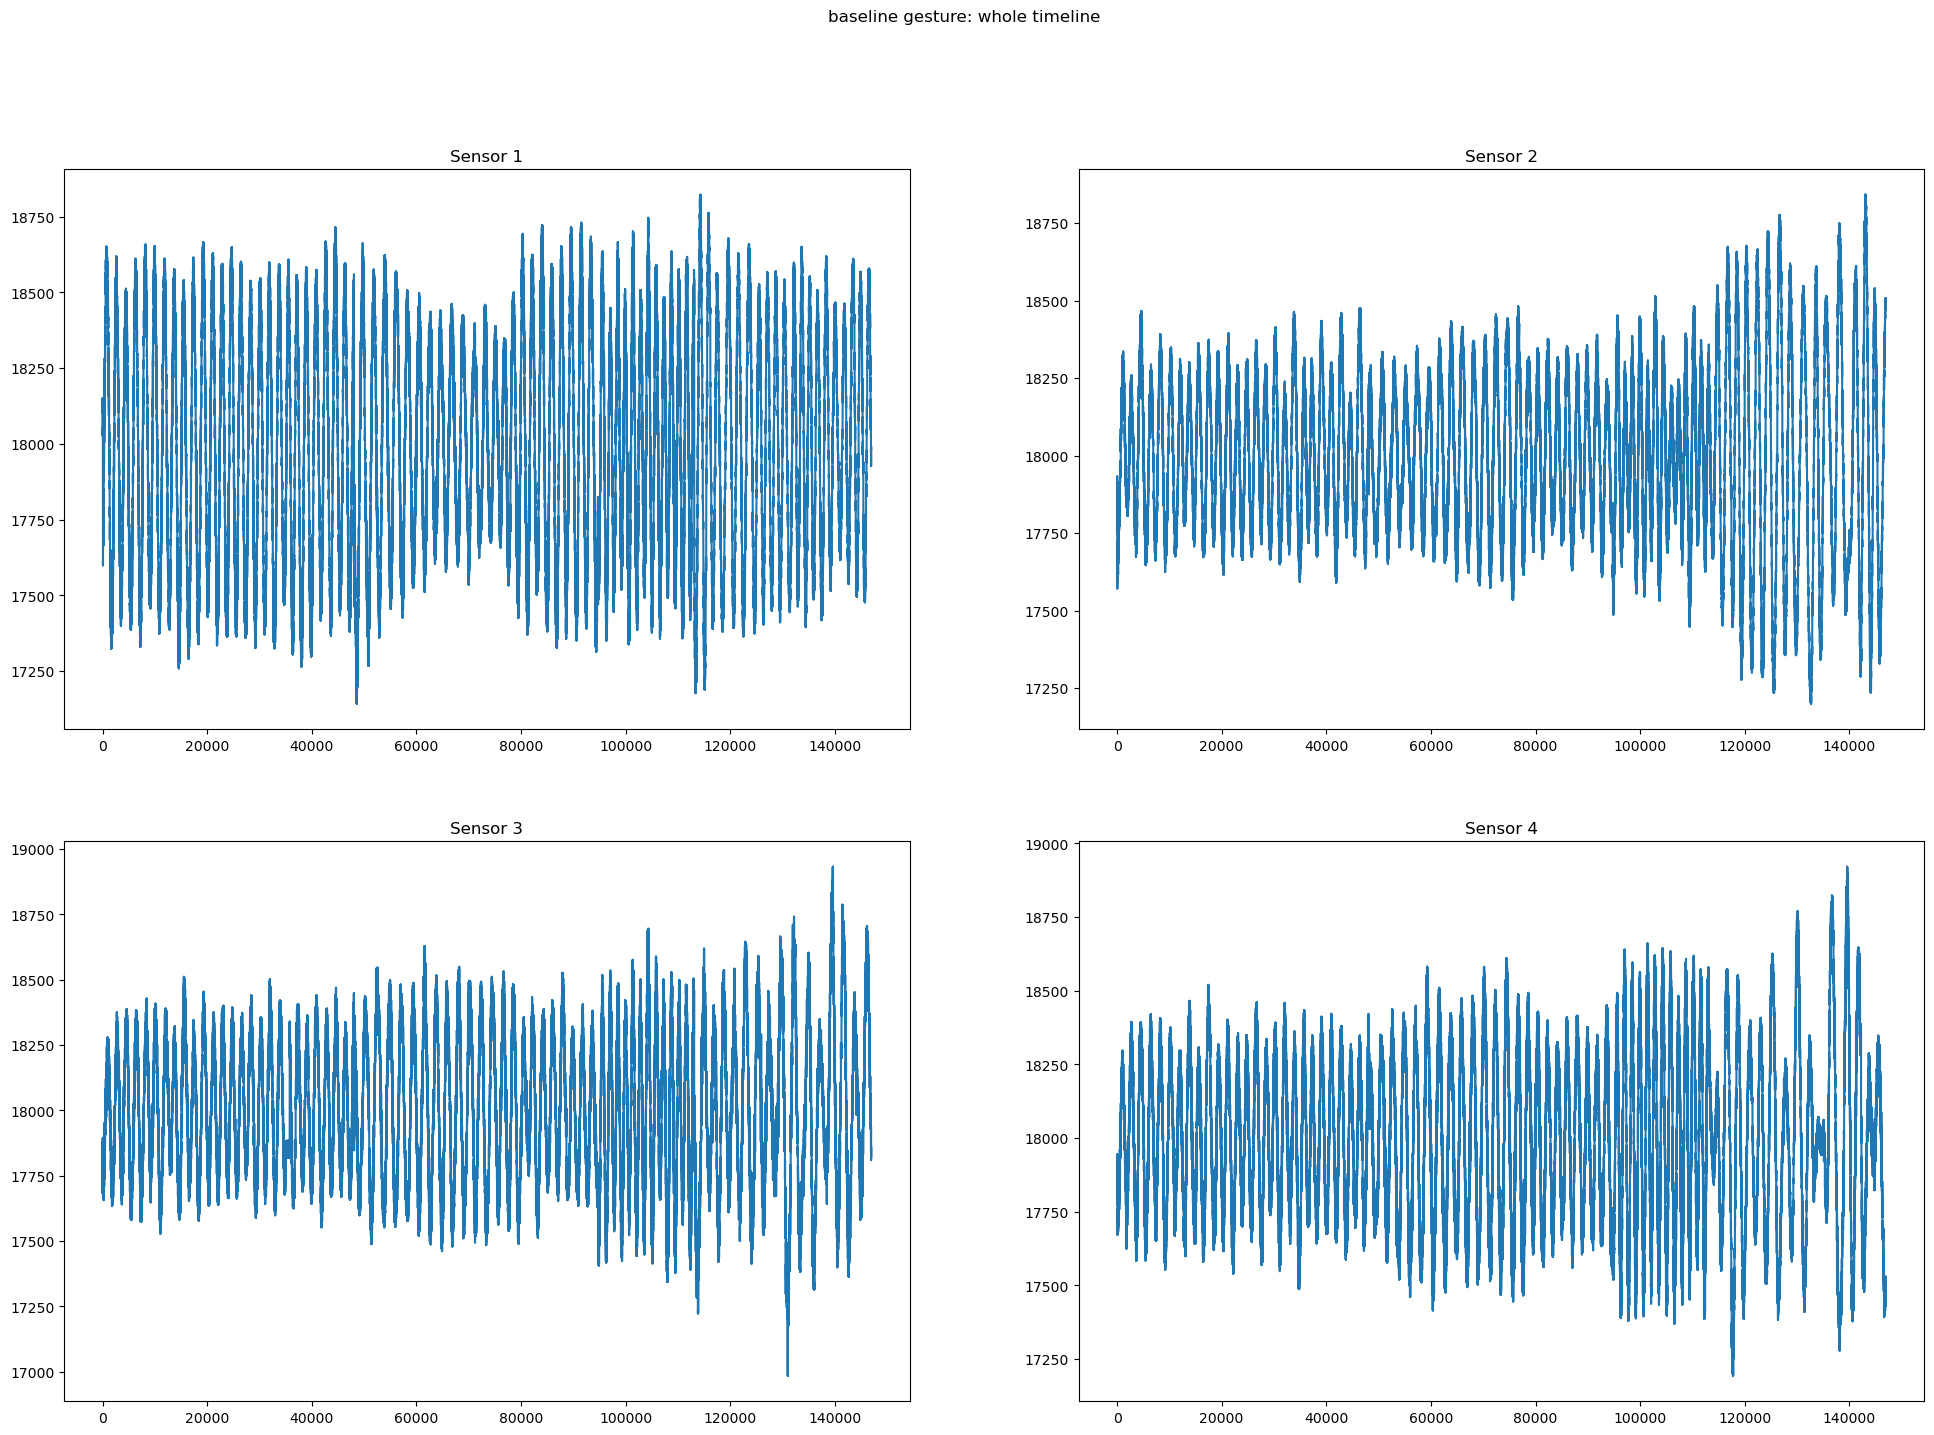

Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]
Raw SNR:  [inf]
Processed SNR:  [inf]


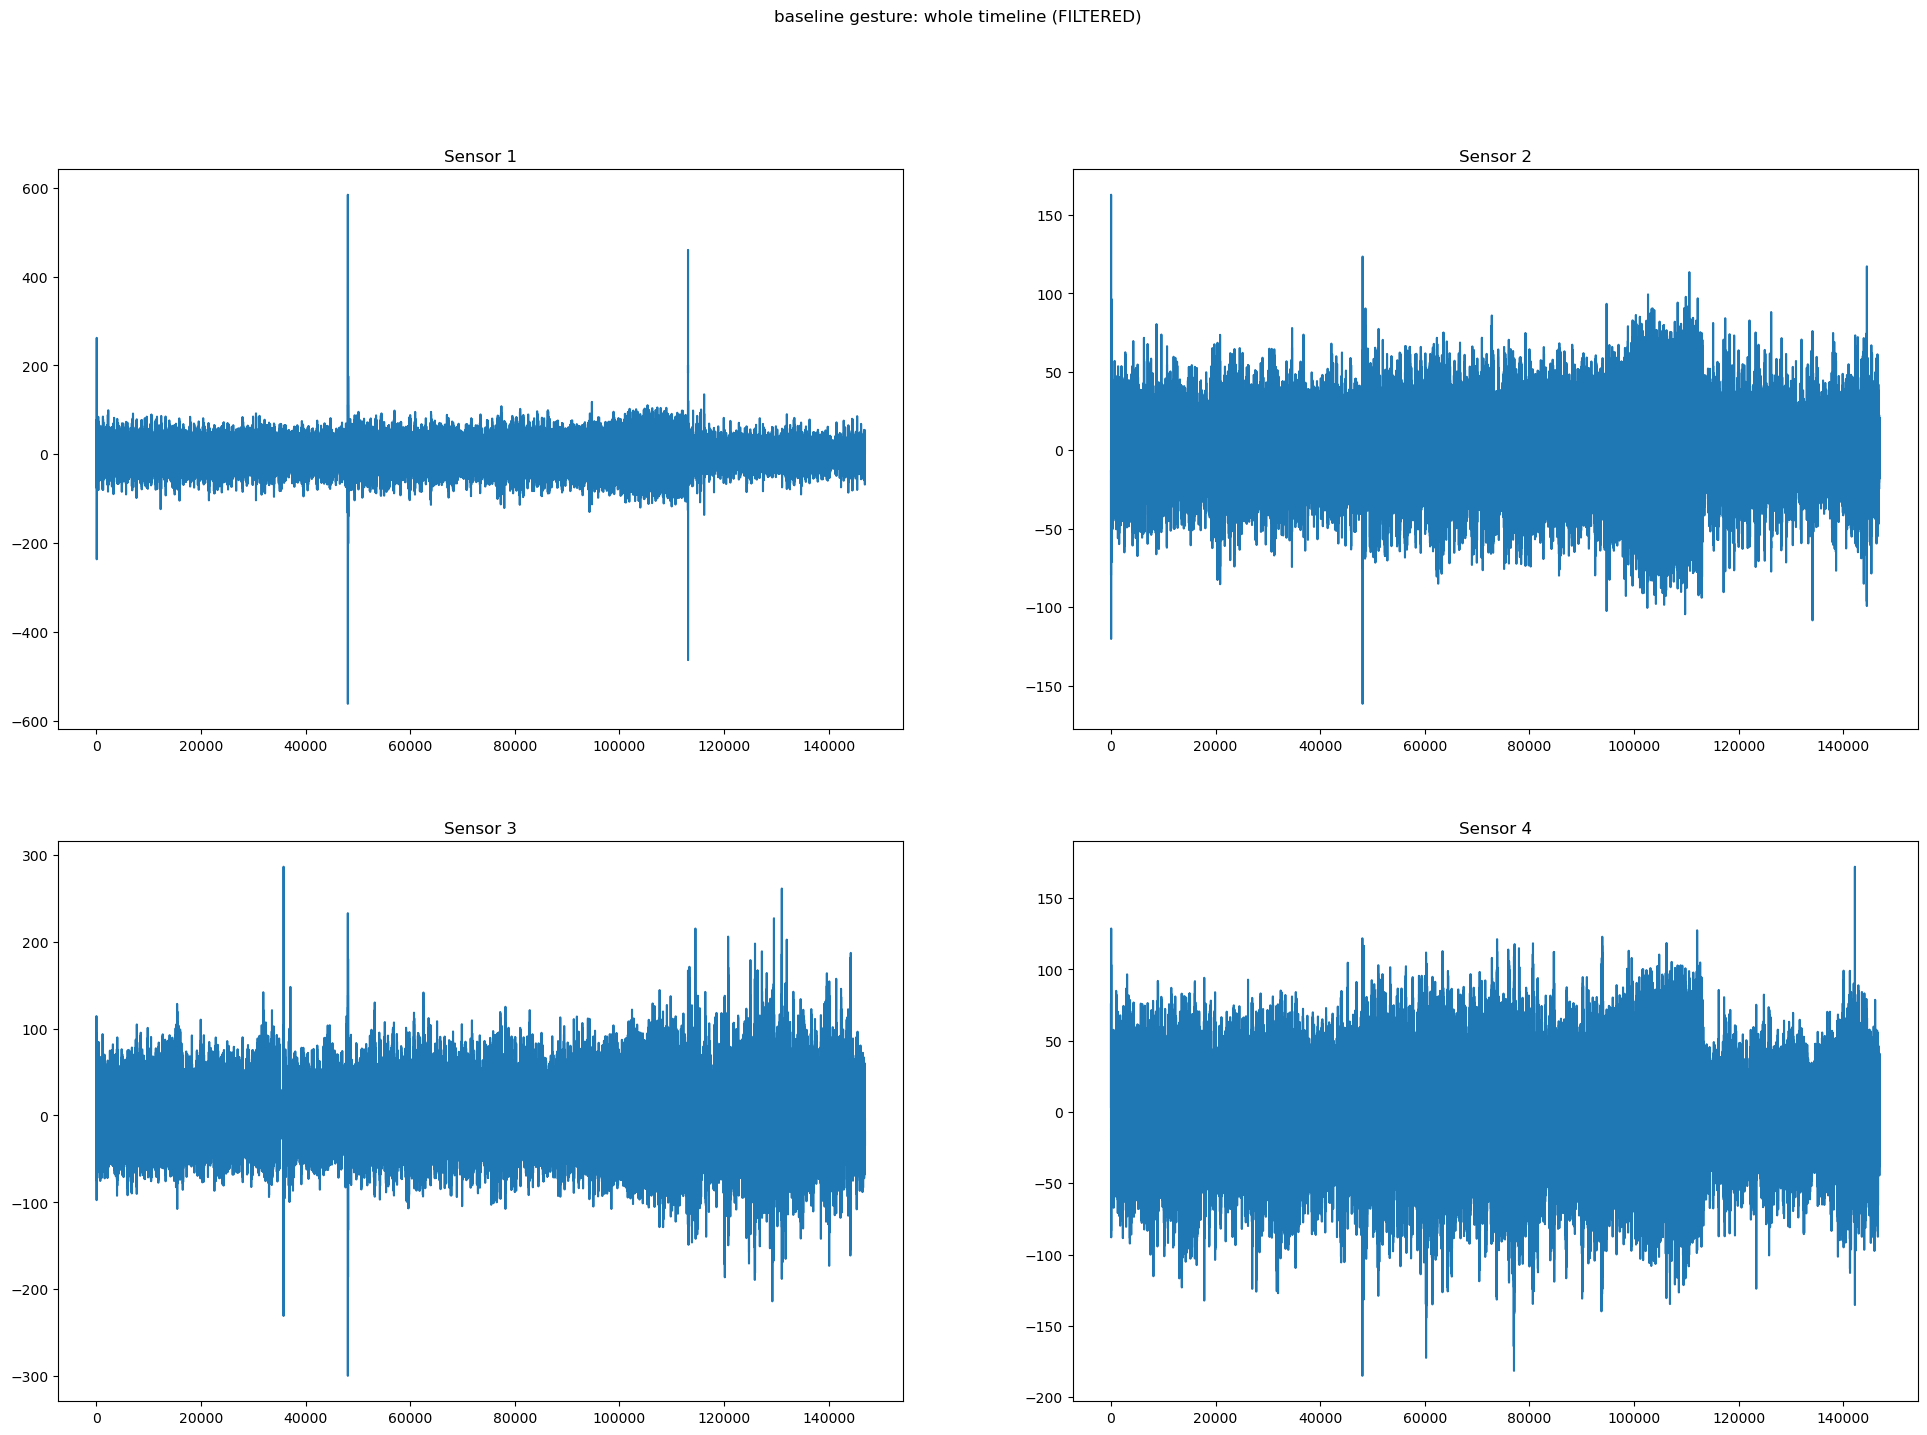

In [130]:
preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, None, filter_type='band', library='libemg', num_sensors=NUM_SENSORS)

if PLOT_ALL_TIMELINE:
    for i in range(NUM_CLASSES):
        plot_all_time_signals(concat_dfs[i], title=f'{GESTURES[i]} gesture: whole timeline')
        plot_all_time_signals(concat_dfs[i], title=f'{GESTURES[i]} gesture: whole timeline (FILTERED)', preprocessor=preprocessor, filter=True)

## Class distribution

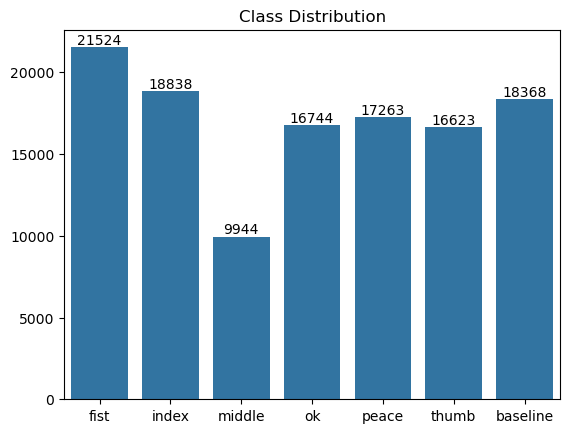

In [131]:
ax = sns.barplot(x=GESTURES, y=[len(df) for df in concat_dfs])
ax.bar_label(ax.containers[0])

plt.title('Class Distribution')
plt.show()

## Sensor correlation analysis

/tmp/ipykernel_5486/2709244429.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()


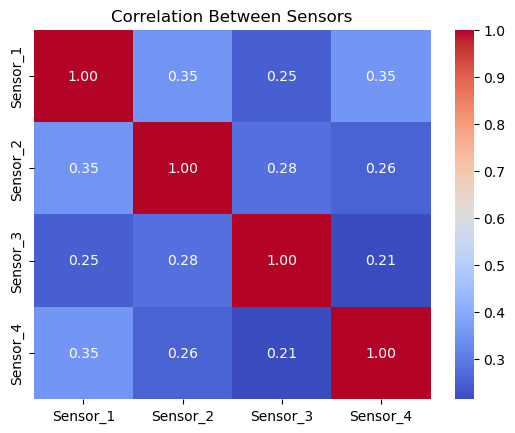

In [132]:
sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()

sensor_means.columns = [f"Sensor_{i+1}" for i in range(NUM_SENSORS)]

correlation = sensor_means.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Sensors")
plt.show()

## Dimensionality Reduction

/home/madnad/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


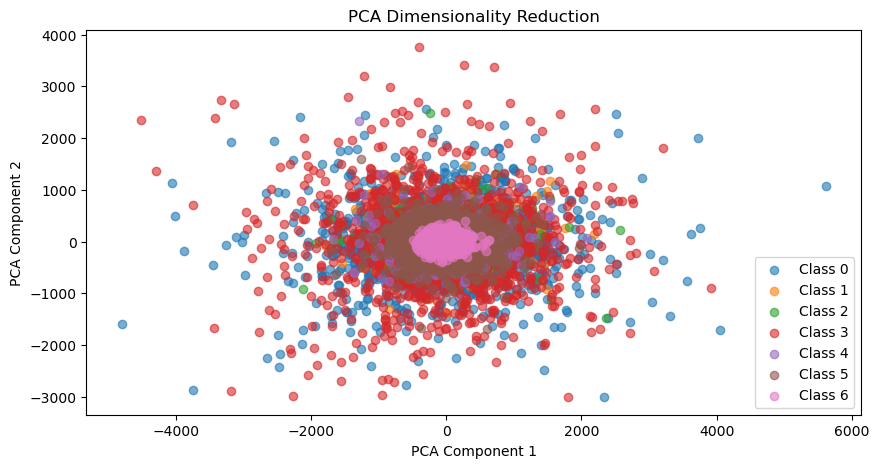

In [133]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=2)
shape = sensor_data.shape
sensor_data_array = concat_dfs
sensor_preproc = [[] for _ in range(NUM_CLASSES)]
for i in range(NUM_CLASSES):
    shape_per_sensor = sensor_data_array[i].shape
    signals = np.array_split(sensor_data_array[i], NUM_SENSORS, axis=1)
    for sensor in range(0, NUM_SENSORS):
        sigs = signals[sensor]
        sig_shape = sigs.shape
        sigs = np.array(sigs).flatten()
        sigs = preprocessor.preprocess(sigs, sensor)
        sigs = sigs.reshape(sig_shape)
        signals[sensor] = sigs

    sensor_preproc[i] = np.asarray(signals).reshape(shape_per_sensor)
    
sensor_preproc = np.concatenate(sensor_preproc)
pca_result = pca.fit_transform(sensor_preproc)

# Plot PCA results
plt.figure(figsize=(10, 5))
for class_id in np.unique(labels):
    plt.scatter(pca_result[labels == class_id, 0], pca_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("PCA Dimensionality Reduction")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [196]:
# # t-SNE Dimensionality Reduction to 2 components
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
tsne_result = tsne.fit_transform(sensor_preproc)

# Plot t-SNE results
plt.figure(figsize=(10, 5))
for class_id in np.unique(labels):
    plt.scatter(tsne_result[labels == class_id, 0], tsne_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("t-SNE Dimensionality Reduction")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

KeyboardInterrupt: 

## Train networks

In [134]:
preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, None, filter_type='band', library='libemg')

In [135]:
from libemg.utils import get_windows
from libemg.feature_extractor import FeatureExtractor

def preprocess_per_sensor(df, preprocessor, class_name, num_sensors=4, window_size=200, window_increment=100):
    raw_signal = df.values
    signals = np.array_split(raw_signal, num_sensors, axis=1)
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        sigs = preprocessor.preprocess(sigs, sensor)
        sigs = sigs.reshape(-1, 8)
        signals[sensor] = sigs
    raw_signal = np.concatenate(signals, axis=1)
    raw_signal = np.hstack([raw_signal[:, i::8] for i in range(8)])
    raw_signal = raw_signal.reshape(-1, num_sensors)
    raw_signal = get_windows(raw_signal, window_size=window_size, window_increment=window_increment)
    
    features_preshaped = raw_signal
    raw_signal = raw_signal.reshape(raw_signal.shape[0], -1)
    raw_signal = np.hstack((raw_signal, np.full((raw_signal.shape[0], 1), class_name)))
    return raw_signal, features_preshaped

def get_features_per_sensor(windows, feature_groups=('HTD',)):
    fe = FeatureExtractor()
    
    features_list = []
    
    for feature_group in feature_groups:
        if feature_group not in fe.get_feature_groups().keys():
            raise ValueError(f"Invalid feature group: {feature_group}")

        features = fe.extract_feature_group(feature_group, windows, array=True)
        features_list.append(features)
    return np.concatenate(features_list, axis=1)

def check_invalid_features(features, classname, silent=True):
    fe = FeatureExtractor()

    invalid_features = fe.check_features(features, silent=silent)
    print(f'Invalid features for class {classname}: ', invalid_features)

In [136]:
windows = [[] for _ in range(NUM_CLASSES)]
data_arrays = [[] for _ in range(NUM_CLASSES)]
for i, df in enumerate(concat_dfs):
    data_arrays[i], windows[i] = preprocess_per_sensor(df, preprocessor, i, num_sensors=NUM_SENSORS, window_size=400, window_increment=50)

features = [[] for _ in range(NUM_CLASSES)]
for i in range(NUM_CLASSES):
    features[i] = np.hstack((get_features_per_sensor(windows[i], feature_groups=('HJORTH', 'HTD')), np.full((windows[i].shape[0], 1), i)))

In [137]:
X = np.vstack([arr[:, :-1] for arr in data_arrays])
y = np.hstack([arr[:, -1] for arr in data_arrays])

X_feat = np.vstack([arr[:, :-1] for arr in features])
y_feat = y

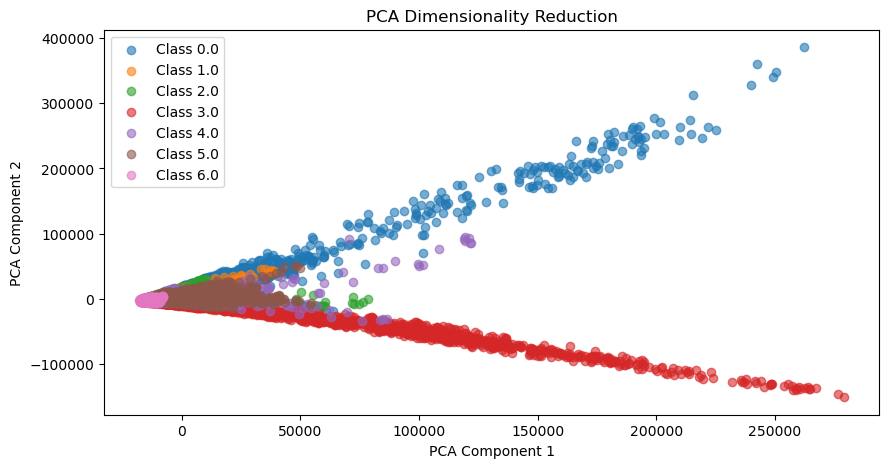

In [138]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_feat)

# Plot PCA results
plt.figure(figsize=(10, 5))
for class_id in np.unique(y_feat):
    plt.scatter(pca_result[y_feat == class_id, 0], pca_result[y_feat == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("PCA Dimensionality Reduction")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [124]:
# # t-SNE Dimensionality Reduction to 2 components
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
tsne_result = tsne.fit_transform(X_feat)

# Plot t-SNE results
plt.figure(figsize=(10, 5))
for class_id in np.unique(y_feat):
    plt.scatter(tsne_result[y_feat == class_id, 0], tsne_result[y_feat == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("t-SNE Dimensionality Reduction")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

KeyboardInterrupt: 

In [139]:
print(X.shape, y.shape, X_feat.shape, y_feat.shape)

(19037, 1600) (19037,) (19037, 28) (19037,)


In [140]:
print(X.max(), X.min(), X_feat.max(), X_feat.min())

2905.761823076309 -2944.1335038134557 418900.5836294623 0.2680791083314377


Use separate scalars for raw data and features and save both:

In [141]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

with open("scaler_raw_data.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [ ]:
scaler = StandardScaler()

X_feat = scaler.fit_transform(X_feat)

with open("scaler_features.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [143]:
print(X.max(), X.min(), X_feat.max(), X_feat.min())

45.595213797389356 -45.547342301772794 21.372314370286325 -6.698519627151143


In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)
X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(X_feat, y_feat, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

In [145]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape
X_train_feat.shape, X_test_feat.shape, y_train_feat.shape, y_test_feat.shape

((15229, 28), (3808, 28), (15229,), (3808,))

In [146]:
# Count classes in y_test
unique, counts = np.unique(y_test, return_counts=True)
unique, counts

(array([0., 1., 2., 3., 4., 5., 6.]),
 array([665, 600, 337, 552, 570, 527, 557]))

## Classical models

In [147]:
clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', max_depth=100, random_state=RANDOM_STATE)
# clf.fit(X_train, y_train)
clf.fit(X_train_feat, y_train_feat)

RandomForestClassifier(max_depth=100, random_state=42)

In [148]:
depths = [estimator.get_depth() for estimator in clf.estimators_]
min(depths), max(depths)

(23, 35)

In [149]:
with open("random_forest_model.pkl", "wb") as f:
    dump(clf, f, protocol=5)

In [150]:
y_pred = clf.predict(X_train_feat)

print('Classification Report: \n', classification_report(y_train_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train_feat, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2771
         1.0       1.00      1.00      1.00      2407
         2.0       1.00      1.00      1.00      1247
         3.0       1.00      1.00      1.00      2120
         4.0       1.00      1.00      1.00      2185
         5.0       1.00      1.00      1.00      2125
         6.0       1.00      1.00      1.00      2374

    accuracy                           1.00     15229
   macro avg       1.00      1.00      1.00     15229
weighted avg       1.00      1.00      1.00     15229

Confusion Matrix: 
 [[2771    0    0    0    0    0    0]
 [   0 2407    0    0    0    0    0]
 [   0    0 1247    0    0    0    0]
 [   0    0    0 2120    0    0    0]
 [   0    0    0    0 2185    0    0]
 [   0    0    0    0    0 2125    0]
 [   0    0    0    0    0    0 2374]]


In [151]:
y_pred = clf.predict(X_test_feat)

In [152]:
print('Classification Report: \n', classification_report(y_test_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test_feat, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       665
         1.0       0.86      0.92      0.89       600
         2.0       0.95      0.95      0.95       337
         3.0       0.96      0.96      0.96       552
         4.0       0.91      0.87      0.89       570
         5.0       0.89      0.87      0.88       527
         6.0       1.00      1.00      1.00       557

    accuracy                           0.93      3808
   macro avg       0.93      0.93      0.93      3808
weighted avg       0.93      0.93      0.93      3808

Confusion Matrix: 
 [[643   0   0  22   0   0   0]
 [  0 551   5   0  14  30   0]
 [  0   2 320   0  12   2   1]
 [ 22   0   0 530   0   0   0]
 [  0  43  10   0 495  22   0]
 [  0  47   1   0  22 457   0]
 [  0   0   0   0   0   0 557]]


In [153]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(7)
clf.fit(X_train_feat, y_train_feat)

KNeighborsClassifier(n_neighbors=7)

In [154]:
y_pred = clf.predict(X_test_feat)
print('Classification Report: \n', classification_report(y_test_feat, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test_feat, y_pred))

Classification Report: 
               precision    recall  f1-score   support

         0.0       0.98      0.97      0.98       665
         1.0       0.81      0.93      0.87       600
         2.0       0.88      0.88      0.88       337
         3.0       0.97      0.99      0.98       552
         4.0       0.87      0.85      0.86       570
         5.0       0.93      0.80      0.86       527
         6.0       0.95      0.96      0.96       557

    accuracy                           0.91      3808
   macro avg       0.91      0.91      0.91      3808
weighted avg       0.92      0.91      0.91      3808

Confusion Matrix: 
 [[648   2   0  15   0   0   0]
 [  0 558   8   0  18  13   3]
 [  1  26 295   0  11   1   3]
 [  8   0   0 544   0   0   0]
 [  1  37  23   0 482  13  14]
 [  0  53   5   0  43 420   6]
 [  0  11   3   0   3   4 536]]


In [155]:
with open("knn.pkl", "wb") as f:
    dump(clf, f, protocol=5)

## Test different classical ML models

Testing different classification models with common parameters based on https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html.

In [195]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=RANDOM_STATE),
    SVC(gamma=2, C=1, random_state=RANDOM_STATE),
    DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=RANDOM_STATE
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=RANDOM_STATE),
    AdaBoostClassifier(algorithm="SAMME", random_state=RANDOM_STATE),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

for name, clf in zip(names, classifiers):
    clf.fit(X_train_feat, y_train_feat)
    y_pred = clf.predict(X_test_feat)
    
    print(f'{name} results:')
    print('Classification Report: \n', classification_report(y_test_feat, y_pred))
    print('Confusion Matrix: \n', confusion_matrix(y_test_feat, y_pred))
    print()

Nearest Neighbors results:
Classification Report: 
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       148
         1.0       1.00      1.00      1.00       135
         2.0       0.96      0.99      0.97       143
         3.0       0.99      1.00      1.00       120
         4.0       1.00      0.97      0.98       130
         5.0       0.99      0.98      0.99       112
         6.0       0.99      0.99      0.99       149

    accuracy                           0.99       937
   macro avg       0.99      0.99      0.99       937
weighted avg       0.99      0.99      0.99       937

Confusion Matrix: 
 [[146   0   2   0   0   0   0]
 [  0 135   0   0   0   0   0]
 [  1   0 141   1   0   0   0]
 [  0   0   0 120   0   0   0]
 [  0   0   4   0 126   0   0]
 [  0   0   0   0   0 110   2]
 [  0   0   0   0   0   1 148]]

Linear SVM results:
Classification Report: 
               precision    recall  f1-score   support

         0.0

The models used in by libemg are also based on Scikit-Learn and mostly use the [standard parameters](https://github.com/LibEMG/libemg/blob/main/libemg/emg_predictor.py#L225):

```python
model_config = {
    'LDA': (LinearDiscriminantAnalysis, {}),
    'KNN': (KNeighborsClassifier, {"n_neighbors": 5}),
    'SVM': (SVC, {"kernel": "linear", "probability": True, "random_state": 0}),
    'QDA': (QuadraticDiscriminantAnalysis, {}),
    'RF': (RandomForestClassifier, {"random_state": 0}),
    'NB': (GaussianNB, {}),
    'GB': (GradientBoostingClassifier, {"random_state": 0}),
    'MLP': (MLPClassifier, {"random_state": 0, "hidden_layer_sizes": 126})
}
```

## Deep Learning

### Feed Forward Neural Network

The FFNN will be trained on the extracted features from the EMG signals.

In [156]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, layer_sizes, dropout_rates):
        super(NeuralNet, self).__init__()
        
        assert len(layer_sizes) >= 2, "layer_sizes must include at least input and output sizes"
        assert len(dropout_rates) == len(layer_sizes) - 2, "dropout_rates must match the number of hidden layers"
        
        layers = []
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(dropout_rates):  # Apply dropout only to hidden layers
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout_rates[i]))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)


In [157]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [158]:
def train_model(model, train_dataloader, test_loader, n_epochs, learning_rate, verbose=True):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1)
    
    for epoch in range(n_epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        model.train()
        for inputs, labels in train_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute running loss and accuracy
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        test_accuracy, test_loss = calculate_accuracy(model, test_loader)

        scheduler.step(running_loss / total)
        
        if verbose:
            epoch_loss = running_loss / len(train_dataloader.dataset)
            epoch_accuracy = correct / total * 100

            print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

    return model

def calculate_accuracy(model, test_dataloader, loss_fn=nn.CrossEntropyLoss()):
    running_loss = 0.0
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return correct / total * 100, running_loss / total

In [159]:
input_size = X_train_feat.shape[1]
output_size = int(y_train_feat.max() + 1)
batch_size = 256
epochs = 200
learning_rate = 0.001

X_train_tensor = torch.tensor(X_train_feat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_feat, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_feat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_feat, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [160]:
models_architectures = [
    {'layer_sizes': [input_size, 1024, 1024, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 128, 32, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 32, 32, output_size], 'dropout_rates': [0.2, 0.2]},
    {'layer_sizes': [input_size, 32, output_size], 'dropout_rates': [0.2]},
    {'layer_sizes': [input_size, 8, output_size], 'dropout_rates': [0.2]},
]

In [161]:
models = []

for i, architecture in enumerate(models_architectures):
    model = NeuralNet(architecture['layer_sizes'], architecture['dropout_rates']).to(device)
    print(f"Training model {i+1} with {sum(p.numel() for p in model.parameters())} weights")
    model = train_model(model, train_loader, test_loader, epochs, learning_rate, verbose=False)
    print(f"Model {i+1} train accuracy: {calculate_accuracy(model, train_loader)[0]:.2f}% test accuracy: {calculate_accuracy(model, test_loader)[0]:.2f}%\n")
    models.append(model)

Training model 1 with 1086471 weights
Model 1 train accuracy: 100.00% test accuracy: 98.63%

Training model 2 with 8071 weights
Model 2 train accuracy: 98.31% test accuracy: 95.33%

Training model 3 with 2215 weights
Model 3 train accuracy: 93.18% test accuracy: 91.07%

Training model 4 with 1159 weights
Model 4 train accuracy: 91.53% test accuracy: 88.87%

Training model 5 with 295 weights
Model 5 train accuracy: 77.14% test accuracy: 75.55%



In [162]:
model_scripted = torch.jit.script(models[1])
model_scripted.save('ffnn_model.pt')

In [193]:
model_scripted = torch.jit.script(models[3])
model_scripted.save('ffnn_model_2.pt')

In [194]:
X_test_tensor[7], y_test_tensor[7]

(tensor([-0.2377, -0.3206, -0.4774, -0.4002,  1.2901,  0.3609, -0.1596,  0.6456,
          0.3942,  2.1458,  2.3401,  1.1795, -0.4122, -0.6136, -0.7332, -0.5497,
          0.0438,  0.1735,  0.0746,  0.7247, -0.7351,  0.9884,  0.9316,  0.2641,
         -0.2948, -0.7114, -0.7981, -0.3919]),
 tensor(2))

In [100]:
logits = models[0](X_test_tensor[7].unsqueeze(0).to(device))
shifted_logits = logits - logits.min(dim=1, keepdim=True).values
normalized_logits = shifted_logits / (shifted_logits.sum(dim=1, keepdim=True) + 1e-8)
print(logits)
print(normalized_logits)

tensor([[-40.5184,  -1.1156,  -2.7805, -17.2711, -15.9246,  25.0549]],
       grad_fn=<AddmmBackward0>)
tensor([[0.0000, 0.2068, 0.1980, 0.1220, 0.1291, 0.3441]],
       grad_fn=<DivBackward0>)


In [81]:
gc.collect()

327

### LSTM (Long Short-Term Memory)

Unlike the FFNN that was trained on the extracted features, the LSTM will be trained on the raw EMG signals (time series).

In [130]:
class PureLSTM(nn.Module):

    def __init__(self, n_features, n_hidden, n_sequence, n_layers, n_classes, bidirectional=False):
        super(PureLSTM, self).__init__()

        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_sequence = n_sequence
        self.n_layers = n_layers
        self.n_classes = n_classes
        self.bidirectional = bidirectional

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=n_hidden,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        self.linear_1 = nn.Linear(in_features=n_hidden * (2 if bidirectional else 1), out_features=128)
        self.dropout_1 = nn.Dropout(p=0.2)

        self.linear_2 = nn.Linear(in_features=128, out_features=n_classes)

    def forward(self, x):
        device = x.device
        hidden = (
            torch.zeros(self.n_layers * (2 if self.bidirectional else 1), x.shape[0], self.n_hidden).to(device),
            torch.zeros(self.n_layers * (2 if self.bidirectional else 1), x.shape[0], self.n_hidden).to(device),
        )

        out, (hs, cs) = self.lstm(x.view(len(x), self.n_sequence, -1), hidden)
        out = out[:, -1, :]

        out = self.linear_1(out)
        out = self.dropout_1(out)
        out = self.linear_2(out)

        return out

In [163]:
n_features = NUM_SENSORS
n_sequence = int(X_train.shape[1] / n_features)
epochs = 200
learning_rate = 0.005

print("Train Data Shape ",X_train.shape, y_train.shape)
print("Test Data Shape ",X_test.shape, y_test.shape)

X_train_mod = X_train.reshape(X_train.shape[0], n_features, n_sequence)
X_train_mod = np.swapaxes(X_train_mod, 2, 1)

X_test_mod = X_test.reshape(X_test.shape[0], n_features, n_sequence)
X_test_mod = np.swapaxes(X_test_mod, 2, 1)

print("Train Data Shape ",X_train_mod.shape)
print("Test Data Shape ",X_test_mod.shape)

X_train_tensor = torch.tensor(X_train_mod, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_mod, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train Data Shape  (15229, 1600) (15229,)
Test Data Shape  (3808, 1600) (3808,)
Train Data Shape  (15229, 400, 4)
Test Data Shape  (3808, 400, 4)


In [164]:
n_hidden = 16
n_layers = 2
model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size, bidirectional=False).to(device)

NameError: name 'PureLSTM' is not defined

In [133]:
print(model)
print(f"Number of weights: {sum(p.numel() for p in model.parameters())}")

PureLSTM(
  (lstm): LSTM(5, 16, num_layers=2, batch_first=True)
  (linear_1): Linear(in_features=16, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (linear_2): Linear(in_features=128, out_features=9, bias=True)
)
Number of weights: 6985


In [134]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 2.1403, Accuracy: 17.29%, Test Accuracy: 23.88%
Epoch 2/200, Loss: 1.8765, Accuracy: 27.71%, Test Accuracy: 30.64%
Epoch 3/200, Loss: 1.6664, Accuracy: 35.30%, Test Accuracy: 39.93%
Epoch 4/200, Loss: 1.5516, Accuracy: 40.75%, Test Accuracy: 43.41%
Epoch 5/200, Loss: 1.5646, Accuracy: 38.93%, Test Accuracy: 35.45%
Epoch 6/200, Loss: 1.5554, Accuracy: 39.13%, Test Accuracy: 41.94%
Epoch 7/200, Loss: 1.4679, Accuracy: 42.84%, Test Accuracy: 41.14%
Epoch 8/200, Loss: 1.5783, Accuracy: 38.78%, Test Accuracy: 38.66%
Epoch 9/200, Loss: 1.5001, Accuracy: 41.17%, Test Accuracy: 32.31%
Epoch 10/200, Loss: 1.8330, Accuracy: 29.31%, Test Accuracy: 31.24%
Epoch 11/200, Loss: 1.6499, Accuracy: 35.57%, Test Accuracy: 36.92%
Epoch 12/200, Loss: 1.5105, Accuracy: 40.47%, Test Accuracy: 41.20%
Epoch 13/200, Loss: 1.4691, Accuracy: 41.82%, Test Accuracy: 42.34%
Epoch 14/200, Loss: 1.4560, Accuracy: 42.64%, Test Accuracy: 42.41%
Epoch 15/200, Loss: 1.4179, Accuracy: 43.75%, Test Accura

KeyboardInterrupt: 

In [115]:
model_scripted = torch.jit.script(model)
model_scripted.save('lstm_model.pt')

Try LSTM with bidirectional layers.

In [135]:
n_hidden = 16
n_layers = 2
model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size, bidirectional=True).to(device)

In [136]:
print(model)
print(f"Number of weights: {sum(p.numel() for p in model.parameters())}")

PureLSTM(
  (lstm): LSTM(5, 16, num_layers=2, batch_first=True, bidirectional=True)
  (linear_1): Linear(in_features=32, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (linear_2): Linear(in_features=128, out_features=9, bias=True)
)
Number of weights: 14729


In [137]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 2.1114, Accuracy: 18.38%, Test Accuracy: 25.75%
Epoch 2/200, Loss: 2.1238, Accuracy: 22.58%, Test Accuracy: 26.02%
Epoch 3/200, Loss: 1.8282, Accuracy: 29.87%, Test Accuracy: 35.52%
Epoch 4/200, Loss: 1.6009, Accuracy: 38.51%, Test Accuracy: 34.05%
Epoch 5/200, Loss: 1.5934, Accuracy: 37.63%, Test Accuracy: 38.06%
Epoch 6/200, Loss: 1.5170, Accuracy: 42.11%, Test Accuracy: 39.67%
Epoch 7/200, Loss: 1.7486, Accuracy: 35.30%, Test Accuracy: 44.68%
Epoch 8/200, Loss: 1.5576, Accuracy: 41.72%, Test Accuracy: 39.13%
Epoch 9/200, Loss: 1.5491, Accuracy: 41.62%, Test Accuracy: 43.95%
Epoch 10/200, Loss: 1.4629, Accuracy: 43.80%, Test Accuracy: 47.36%
Epoch 11/200, Loss: 1.4295, Accuracy: 45.90%, Test Accuracy: 49.03%
Epoch 12/200, Loss: 1.3470, Accuracy: 48.80%, Test Accuracy: 47.42%
Epoch 13/200, Loss: 1.3075, Accuracy: 50.12%, Test Accuracy: 53.98%
Epoch 14/200, Loss: 1.3972, Accuracy: 48.51%, Test Accuracy: 47.56%
Epoch 15/200, Loss: 1.3410, Accuracy: 50.90%, Test Accura

KeyboardInterrupt: 

In [119]:
model_scripted = torch.jit.script(model)
model_scripted.save('lstm_bidrection_model.pt')

In [120]:
def evaluateModel(outputs, y):
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y).sum().item() / y.size(0) * 100
    return test_accuracy, predicted

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    y_hat_test = model(X_test_tensor)
    acc, predicted = evaluateModel(y_hat_test, y_test_tensor)
    print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 84.42%


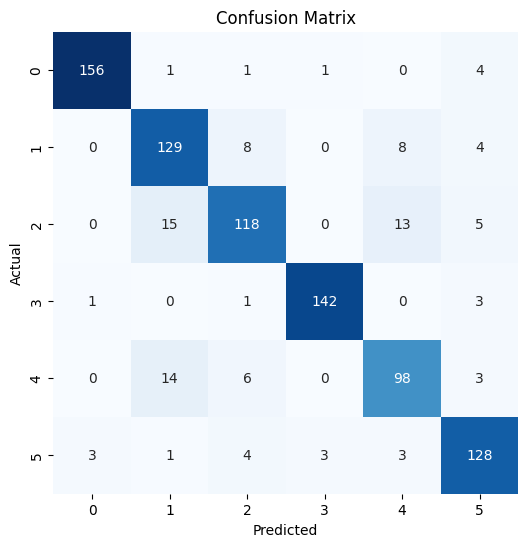

In [117]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [165]:
n_features = NUM_SENSORS
n_sequence = int(X_train_feat.shape[1] / n_features)
n_hidden = 16
n_layers = 2

print("Train Feat Data Shape ",X_train_feat.shape, y_train_feat.shape)
print("Test Feat Data Shape ",X_test_feat.shape, y_test_feat.shape)

X_train_mod = X_train_feat.reshape(X_train_feat.shape[0], n_features, n_sequence)
X_train_mod = np.swapaxes(X_train_mod, 2, 1)

X_test_mod = X_test_feat.reshape(X_test_feat.shape[0], n_features, n_sequence)
X_test_mod = np.swapaxes(X_test_mod, 2, 1)

print("Train Feat Modified Data Shape ",X_train_mod.shape)
print("Test Feat Modified Data Shape ",X_test_mod.shape)

X_train_tensor = torch.tensor(X_train_mod, dtype=torch.float32)
print(X_train_tensor[7])
y_train_tensor = torch.tensor(y_train_feat, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_mod, dtype=torch.float32)
print(X_test_tensor[7])
y_test_tensor = torch.tensor(y_test_feat, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train Feat Data Shape  (15229, 28) (15229,)
Test Feat Data Shape  (3808, 28) (3808,)
Train Feat Modified Data Shape  (15229, 7, 4)
Test Feat Modified Data Shape  (3808, 7, 4)
tensor([[-0.1569, -0.4847,  1.8021, -0.4047],
        [-0.0577,  0.5156, -0.1046,  0.2344],
        [ 0.8899,  0.1192,  0.7625, -0.0150],
        [-0.1386, -1.0795,  0.7788,  0.0507],
        [-0.0753,  0.9703,  1.6469,  0.5189],
        [ 1.1676,  0.0122, -0.4473,  2.2355],
        [ 0.7270,  0.2609, -0.3918, -0.1067]])
tensor([[-0.3044,  1.4685, -0.3763,  0.7063],
        [-0.2873, -0.4210, -0.3805, -0.7450],
        [-0.2909, -0.8743,  0.1958,  1.3558],
        [-0.1935, -0.7396,  0.2536, -0.5750],
        [ 0.6131, -0.7585, -0.6129, -0.3573],
        [ 0.7065, -0.5985,  1.2681, -0.3750],
        [ 0.6297, -0.3704, -0.9367, -0.2551]])


## Transformer

In [166]:
import torch
import torch.nn as nn

class TransformerTimeSeries(nn.Module):
    def __init__(self, n_features, n_sequence, n_hidden, n_heads, n_layers, n_classes, dropout=0.1):
        super(TransformerTimeSeries, self).__init__()
        
        self.n_features = n_features
        self.n_sequence = n_sequence
        
        # Input embedding layer
        self.input_embedding = nn.Linear(n_features, n_hidden)
        
        # Positional encoding
        self.positional_encoding = nn.Parameter(torch.zeros(1, n_sequence, n_hidden))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=n_hidden,
            nhead=n_heads,
            dim_feedforward=n_hidden * 4,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # Fully connected layers
        self.linear_1 = nn.Linear(n_hidden, 128)
        self.dropout_1 = nn.Dropout(p=dropout)
        self.linear_2 = nn.Linear(128, n_classes)

    def forward(self, x):
        # Apply input embedding
        x = self.input_embedding(x)  # Shape: (batch_size, n_sequence, n_hidden)
        
        # Add positional encoding
        x = x + self.positional_encoding
        
        # Pass through Transformer encoder
        x = self.transformer_encoder(x)  # Shape: (batch_size, n_sequence, n_hidden)
        
        # Extract the representation of the last time step
        x = x[:, -1, :]  # Shape: (batch_size, n_hidden)
        
        # Pass through fully connected layers
        x = self.linear_1(x)
        x = self.dropout_1(x)
        x = self.linear_2(x)
        
        return x


In [167]:
n_heads = 4
dropout = 0.2

model = TransformerTimeSeries(n_features, n_sequence, n_hidden, n_heads, n_layers, output_size, dropout).to(device)

In [168]:
model = train_model(model, train_loader, test_loader, epochs, learning_rate)

Epoch 1/200, Loss: 1.1953, Accuracy: 51.04%, Test Accuracy: 60.53%
Epoch 2/200, Loss: 0.8745, Accuracy: 61.30%, Test Accuracy: 64.47%
Epoch 3/200, Loss: 0.7850, Accuracy: 64.58%, Test Accuracy: 68.88%
Epoch 4/200, Loss: 0.6947, Accuracy: 68.41%, Test Accuracy: 72.16%
Epoch 5/200, Loss: 0.6390, Accuracy: 71.03%, Test Accuracy: 69.33%
Epoch 6/200, Loss: 0.5995, Accuracy: 73.18%, Test Accuracy: 78.91%
Epoch 7/200, Loss: 0.5678, Accuracy: 75.03%, Test Accuracy: 78.60%
Epoch 8/200, Loss: 0.5627, Accuracy: 74.95%, Test Accuracy: 81.20%
Epoch 9/200, Loss: 0.5268, Accuracy: 76.57%, Test Accuracy: 81.70%
Epoch 10/200, Loss: 0.5006, Accuracy: 78.36%, Test Accuracy: 81.43%
Epoch 11/200, Loss: 0.5051, Accuracy: 78.30%, Test Accuracy: 82.22%
Epoch 12/200, Loss: 0.4955, Accuracy: 78.51%, Test Accuracy: 82.85%
Epoch 13/200, Loss: 0.4851, Accuracy: 79.47%, Test Accuracy: 82.41%
Epoch 14/200, Loss: 0.4793, Accuracy: 79.33%, Test Accuracy: 82.93%
Epoch 15/200, Loss: 0.4725, Accuracy: 79.72%, Test Accura

In [170]:
model_scripted = torch.jit.script(model)
model_scripted.save('transformer_model.pt')